# Dynamic Cosserat Rod Model

## Overview
This notebook implements a **dynamic Cosserat rod model** with **general/distributed tendon routing** and **time-varying tendon tension**. 

---

## 1. State Vector Representation

The state of the backbone is defined by $Y = [p, R, n, m, q, \omega]$, where:

* $p(s, t) \in \mathbb{R}^3$: Backbone position in the global frame.
* $R(s, t) \in \mathbb{SO}(3)$: Backbone orientation matrix (body $\to$ global frame).
* $n(s, t) \in \mathbb{R}^3$: Internal force vector in the global frame.
* $m(s, t) \in \mathbb{R}^3$: Internal moment vector in the global frame.
* $q(s, t) \in \mathbb{R}^3$: Body-frame translational velocity.
* $\omega(s, t) \in \mathbb{R}^3$: Body-frame angular velocity.

---

## 2. Constitutive Relations

The strain variables $v$ (shear/elongation) and $u$ (curvature/torsion) are **not state variables**. They are recovered algebraically from the internal forces $n$ and moments $m$:

$$v = v^* + K_{\text{se}}^{-1} R^T n$$

$$u = u^* + K_{\text{bt}}^{-1} R^T m$$

Where:
* $v^*, u^*$: Undeformed strain reference configurations.
* $K_{\text{se}}, K_{\text{bt}}$: Stiffness matrices for shear/extension and bending/torsion, respectively.

---

## 3. Governing Equations

### Static Case ($t = 0$)
$$\frac{\partial n}{\partial s} = -f$$

$$\frac{\partial m}{\partial s} = -\left(\frac{\partial p}{\partial s} \times n\right) - l$$

### Dynamic Case ($t > 0$)
$$\frac{\partial n}{\partial s} = -f + \rho A \cdot p_{tt}$$

$$\frac{\partial m}{\partial s} = -\left(\frac{\partial p}{\partial s} \times n\right) - l + \rho J \cdot \omega_t + \omega \times (\rho J \cdot \omega)$$

Where:
* $\rho A$: Mass per unit length.
* $\rho J$: Rotational inertia matrix per unit length.
* $p_{tt}$: Second time-derivative of position in global frame.
* $\omega_t$: Time-derivative of body-frame angular velocity.

---

## 4. Direct Wrench Formulation & Tendon Coupling

Rather than solving a separate differential system for strain derivatives ($\frac{\partial u}{\partial s}, \frac{\partial v}{\partial s}$), distributed tendon forces $f$ and moments $l$ are expressed directly as functions of spatial wrench derivatives:

$$f = f_0 + F_n \frac{\partial n}{\partial s} + F_m \frac{\partial m}{\partial s}$$

$$l = l_0 + L_n \frac{\partial n}{\partial s} + L_m \frac{\partial m}{\partial s}$$

The boundary value problem (BVP) solves directly for the spatial spatial derivative pair $\left[\frac{\partial n}{\partial s}, \frac{\partial m}{\partial s}\right]^T$.

---

## 5. Time Discretization Scheme

Time derivatives ($p_t, p_{tt}, \omega_t$) are discretized using backward differentiation formulas (BDF):

* **$t = 0$**: Static equilibrium solve.
* **$t = \Delta t$**: First-order Backward Differentiation Formula (**BDF1** / Implicit Euler).
* **$t \ge 2\Delta t$**: Second-order Backward Differentiation Formula (**BDF2**).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from scipy.optimize import root
import math
import xml.etree.ElementTree as ET
from xml.dom import minidom
from typing import List, Dict
import time
import mujoco
import mujoco.viewer
from pathlib import Path
import argparse
from numpy.polynomial.legendre import leggauss

In [65]:
# ============================================================
# 1. BASIC OPERATIONS
# ============================================================
def hat(x):
    """Skew-symmetric matrix such that hat(x) @ y = x cross y"""
    x1, x2, x3 = x
    return np.array([[0.0, -x3,  x2], [x3,  0.0, -x1], [-x2, x1,  0.0]])

def orthonormalize(R):
    """Project a numerically drifted matrix onto SO(3)."""
    U, _, Vt = np.linalg.svd(R)
    Rproj = U @ Vt

    if np.linalg.det(Rproj) < 0.0: U[:, -1] *= -1.0; Rproj = U @ Vt
    return Rproj


In [66]:
# ============================================================
# 2. DIFFERENT TENDON
# ============================================================
@dataclass
class Tendon:
    """
    General tendon routing.
    rho(s) tendon position in local backbone frame
    rho_s(s) spatial derivative of rho
    rho_ss(s)second spatial derivative of rho
    tension(t) time-varying tendon tension
    """
    rho: callable
    rho_s: callable
    rho_ss: callable
    tension: callable
    name: str = "tendon"

# ============================================================
# 3. GENERAL TENDON 
# ============================================================
def make_general_tendon(rho, rho_s, rho_ss, tension_function,  name="tendon"):
    return Tendon(rho=rho, rho_s=rho_s, rho_ss=rho_ss,
        tension=tension_function, name=name)

def make_helical_tendon(L, radius, turns, tension_function, phase=0.0, name="helical"):
    """
    General helical tendon routing.
        rho(s) = [r cos(phi), r sin(phi), 0]
        phi(s) = 2*pi*turns*s/L + phase
    """
    phi = (2.0* np.pi* turns* s/ L+ phase)
    phi_s = (2.0* np.pi* turns/ L)
    def rho(s):
        return np.array([radius * np.cos(phi), radius * np.sin(phi), 0.0])
    
    def rho_s(s):
        return np.array([-radius* np.sin(phi)* phi_s, radius* np.cos(phi)* phi_s, 0.0])

    def rho_ss(s):
        return np.array([-radius* np.cos(phi)* phi_s**2, -radius* np.sin(phi)* phi_s**2, 0.0])

    return Tendon(rho=rho,rho_s=rho_s,rho_ss=rho_ss, tension=tension_function,name=name)


def make_straight_tendon(radius, angle, tension_function, name="straight"):
    """Straight tendon at constant offset.angle is in radians."""

    rho_const = np.array([radius * np.cos(angle), radius * np.sin(angle), 0.0])
    def rho(s):return rho_const.copy()
    def rho_s(s):return np.zeros(3)
    def rho_ss(s): return np.zeros(3)
    return Tendon(rho=rho, rho_s=rho_s, rho_ss=rho_ss, tension=tension_function, name=name)

In [67]:
# ============================================================
# 3. COSSERAT/KIRCHHOFF ROD MODELS
# ============================================================
class DynamicCosserat_Kirchhoff:
    def __init__(self, L=0.20, E=1e7, G=5e6, radius=0.005, density=1000.0, u_star=None, v_star=None, crt=False):
        self.L = L
        self.E = E
        self.G = G
        self.radius = radius
        self.density = density
        self.crt = crt

        self.u_star = np.zeros(3) if u_star is None else np.asarray(u_star, dtype=float)
        self.v_star = np.array([0.0, 0.0, 1.0]) if v_star is None else np.asarray(v_star, dtype=float)

        self.A = np.pi * radius**2
        self.Ix = np.pi * radius**4 / 4.0
        self.Iy = self.Ix
        self.Jpolar = self.Ix + self.Iy

        self.mu = density * self.A
        self.J = np.diag([self.Ix, self.Iy, self.Jpolar])
        self.rhoJ = density * self.J

        self.Kse = np.diag([G * self.A, G * self.A, E * self.A])
        self.Kbt = np.diag([E * self.Ix, E * self.Iy, G * self.Jpolar])
        self.Kse_inv = np.diag([1.0 / (G * self.A), 1.0 / (G * self.A), 1.0 / (E * self.A)])
        self.Kbt_inv = np.diag([1.0 / (E * self.Ix), 1.0 / (E * self.Iy), 1.0 / (G * self.Jpolar)])

        self.v_star_s = np.zeros(3)
        self.u_star_s = np.zeros(3)

    @staticmethod
    def pack_state(p, R, n, m, q, omega):
        out = np.empty(24)
        out[0:3] = p
        out[3:12] = R.reshape(9)
        out[12:15] = n
        out[15:18] = m
        out[18:21] = q
        out[21:24] = omega
        return out

    @staticmethod
    def unpack_state(Y):
        return Y[0:3], Y[3:12].reshape(3, 3), Y[12:15], Y[15:18], Y[18:21], Y[21:24]

    def strain_from_wrench(self, R, n, m):
        n_body = R.T @ n
        m_body = R.T @ m
        v = (self.v_star + self.Kse_inv @ n_body) if self.crt else self.v_star
        u = self.u_star + self.Kbt_inv @ m_body
        return v, u, n_body, m_body

In [82]:
# ============================================================
# 4. OPTIMIZED NUMERICAL SOLVER RUCKER PAPER REPLICATION
# ============================================================

class DynamicCosseratSolver:
    def __init__(self, rod, tendons, dt, gravity=None, tip_force=None, tip_moment=None, rtol=1e-6, atol=1e-6, max_step=None):
        self.rod = rod
        self.tendons = tendons
        self.N_tendons = len(tendons)
        self.dt = dt

        self.gravity = np.zeros(3) if gravity is None else np.asarray(gravity, dtype=float)
        self.fe = rod.mu * self.gravity
        self.le = np.zeros(3)

        self.tip_force = (lambda t: np.zeros(3)) if tip_force is None else (tip_force if callable(tip_force) else lambda t: np.asarray(tip_force, dtype=float))
        self.tip_moment = (lambda t: np.zeros(3)) if tip_moment is None else (tip_moment if callable(tip_moment) else lambda t: np.asarray(tip_moment, dtype=float))

        # rtol/atol now actually used: they set the tolerance that the
        # step-doubling error estimate (_estimate_spatial_error /
        # _check_error_tolerance below) is checked against, since the
        # spatial integrator is a fixed-step RK4 with no adaptivity of its
        # own. max_step is accepted for API compatibility but not
        # currently used by the fixed-step integrator (num_points controls
        # step size instead).
        self.rtol = rtol
        self.atol = atol
        self.max_step = max_step

        self.last_base_guess = np.zeros(6)

    @staticmethod
    def bdf_derivative(current, previous, previous_previous, dt, order):
        if order == 1:
            return (current - previous) / dt
        alpha = -0.25
        c0 = (1.5 + alpha) / (dt * (1.0 + alpha))
        c1 = -2.0 / dt
        c2 = (0.5 + alpha) / (dt * (1.0 + alpha))
        d1 = alpha / (1.0 + alpha)
        dot_previous = (previous-previous_previous)/dt
        #return c0*current + c1*previous + c2*previous_previous + d1*dot_previous
        return (3.0 * current - 4.0 * previous + previous_previous) / (2.0 * dt)

    @staticmethod
    def eval_interp_state(s_grid, Y_grid, s_val):
        """Fast 1D linear evaluation along spatial length s."""
        out = np.empty(Y_grid.shape[1])
        for col in range(Y_grid.shape[1]):
            out[col] = np.interp(s_val, s_grid, Y_grid[:, col])
        return out

    def _estimate_spatial_error(self, ode_fn, Y0, s_full):
        """
        Step-doubling (Richardson) accuracy check for the fixed-step RK4
        spatial integration. RK4 is 4th-order accurate, so integrating the
        SAME initial condition Y0 once on the full node grid (step h) and
        once on every other node (step 2h) gives, for the true solution y:
            y - Y_fine   ~ C h^4
            y - Y_coarse ~ C (2h)^4 = 16 C h^4
        so (Y_fine - Y_coarse) ~ 15 C h^4, and the error remaining in the
        fine solution is approximately:
            err ~ (Y_fine - Y_coarse) / 15
        This only measures the local truncation error of the forward
        integration for a fixed shooting parameter z (i.e. how much finer
        sampling would change the answer) -- not the sensitivity of the
        full boundary-value solution to num_points -- but it's a cheap,
        real accuracy signal where previously there was none (fixed-step
        RK4 has no adaptivity/error control of its own).

        Returns (Y_fine, tip_err) where Y_fine is the full-resolution
        trajectory (same as a plain runge_kutta4 call) and tip_err is the
        estimated absolute error on the tip (final) state.
        """
        Y_fine = self.runge_kutta4(ode_fn, s_full, Y0)

        s_coarse = s_full[::2]
        if s_coarse[-1] != s_full[-1]:
            s_coarse = np.append(s_coarse, s_full[-1])
        Y_coarse = self.runge_kutta4(ode_fn, s_coarse, Y0)

        tip_err = np.abs(Y_fine[-1] - Y_coarse[-1]) / 15.0
        return Y_fine, tip_err

    def _check_error_tolerance(self, tip_err, Y_tip, context=""):
        """
        Compare the step-doubling tip-state error estimate against
        rtol/atol (scipy-style: tol = atol + rtol*|y|) and print a
        WARNING if any state component exceeds it. Returns True if within
        tolerance.
        """
        tol = self.atol + self.rtol * np.abs(Y_tip)
        exceeded = tip_err > tol
        if np.any(exceeded):
            worst_ratio = np.max(tip_err / np.maximum(tol, 1e-300))
            print(f"WARNING: estimated spatial discretization error exceeds "
                  f"tolerance ({context}) -- worst component is "
                  f"{worst_ratio:.2f}x over tol (max abs error "
                  f"{np.max(tip_err):.3e}). Consider increasing num_points.")
            return False
        return True

    def tendon_direct_coefficients(self, s, R, n, m, t):
        f0 = np.zeros(3)
        Fn = np.zeros((3, 3))
        Fm = np.zeros((3, 3))
        l0 = np.zeros(3)
        Ln = np.zeros((3, 3))
        Lm = np.zeros((3, 3))

        v, u, n_body, m_body = self.rod.strain_from_wrench(R, n, m)
        hat_u = hat(u)

        if self.rod.crt:
            v_s_cnst = self.rod.v_star_s - self.rod.Kse_inv @ hat_u @ n_body
            Vn = self.rod.Kse_inv @ R.T
        else:
            v_s_cnst = np.zeros(3)
            Vn = np.zeros((3, 3))

        Um = self.rod.Kbt_inv @ R.T
        u_s_cnst = self.rod.u_star_s - self.rod.Kbt_inv @ hat_u @ m_body

        for tendon in self.tendons:
            T_i = tendon.tension(t)
            rho = tendon.rho(s)
            rho_s = tendon.rho_s(s)
            rho_ss = tendon.rho_ss(s)

            hat_rho = hat(rho)
            g = hat_u @ rho + rho_s + v
            p_i_s = R @ g
            p_i_s_norm = np.linalg.norm(p_i_s)

            if p_i_s_norm < 1e-10:
                raise RuntimeError(f"Tendon tangent singular at s={s:.6e}")

            hat_p = hat(p_i_s)
            D = (hat_p @ hat_p) / (p_i_s_norm**3)

            u_s_const_cross_rho = -hat_rho @ u_s_cnst
            H0 = hat_u @ g + u_s_const_cross_rho + hat_u @ rho_s + rho_ss + v_s_cnst
            Hn = Vn
            Hm = -hat_rho @ Um

            P0 = R @ H0
            Pn = R @ Hn
            Pm = R @ Hm

            f_i0 = -T_i * (D @ P0)
            f_in = -T_i * (D @ Pn)
            f_im = -T_i * (D @ Pm)

            moment_arm = R @ rho
            hat_arm = hat(moment_arm)

            l_i0 = hat_arm @ f_i0
            l_in = hat_arm @ f_in
            l_im = hat_arm @ f_im

            f0 += f_i0
            Fn += f_in
            Fm += f_im
            l0 += l_i0
            Ln += l_in
            Lm += l_im

        return f0, Fn, Fm, l0, Ln, Lm

    def tendon_tip_wrench(self, R, n, m, t):
        F_tip = np.zeros(3)
        M_tip = np.zeros(3)
        v, u, _, _ = self.rod.strain_from_wrench(R, n, m)
        
        for tendon in self.tendons:
            T_i = tendon.tension(t)
            rho = tendon.rho(self.rod.L)
            rho_s = tendon.rho_s(self.rod.L)

            g = hat(u) @ rho + rho_s + v
            g_norm = np.linalg.norm(g)
            if g_norm < 1e-10:
                raise RuntimeError(f"Tendon tangent singular at t={t:.6e}")

            tendon_direction = (R @ g) / g_norm
            moment_arm = R @ rho

            F_i = -T_i * tendon_direction
            M_i = np.cross(moment_arm, F_i)
            F_tip += F_i
            M_tip += M_i

        return F_tip, M_tip

    # ============================================================
    # FAST FIXED-STEP RK4 SPATIAL INTEGRATOR
    # ============================================================
    def runge_kutta4(self, ode_func, s_eval, Y0):
        N = len(s_eval)
        Y_res = np.zeros((N, len(Y0)))
        Y_res[0] = Y0

        for i in range(N - 1):
            s_curr = s_eval[i]
            ds = s_eval[i + 1] - s_curr

            y = Y_res[i]

            k1 = ode_func(s_curr, y)
            k2 = ode_func(s_curr + 0.5*ds, y + 0.5*ds*k1)
            k3 = ode_func(s_curr + 0.5*ds, y + 0.5*ds*k2)
            k4 = ode_func(s_curr + ds, y + ds*k3)

            Y_res[i + 1] = y + (ds/6.0)*(k1 + 2*k2 + 2*k3 + k4)

        return Y_res

    def static_spatial_ode(self, s, Y, t, dist_tendon=False, grav=False):
        p = Y[0:3]
        R = Y[3:12].reshape(3, 3)
        n = Y[12:15]
        m = Y[15:18]

        v, u, _, _ = self.rod.strain_from_wrench(R, n, m)
        p_s = R @ v
        R_s = R @ hat(u)

        rhs_n = np.zeros(3)
        rhs_m = -np.cross(p_s, n)
        K = np.eye(6)

        if dist_tendon:
            f0, Fn, Fm, l0, Ln, Lm = self.tendon_direct_coefficients(s, R, n, m, t)
            K11 = np.eye(3) + Fn
            K12 = Fm
            rhs_n += -f0

            K21 = Ln
            K22 = np.eye(3) + Lm
            rhs_m += -l0
            K = np.block([[K11, K12], [K21, K22]])

        if grav:
            rhs_n += -self.fe
            rhs_m += -self.le

        rhs = np.concatenate([rhs_n, rhs_m])
        wrench_derivative = np.linalg.solve(K, rhs)

        out = np.empty(18)
        out[0:3] = p_s
        out[3:12] = R_s.reshape(9)
        out[12:15] = wrench_derivative[0:3]
        out[15:18] = wrench_derivative[3:6]
        return out

    def dynamic_spatial_ode(self, s, Y, t, s_grid, Y_prev_grid, Y_prev_prev_grid, order, dist_tendon=False, grav=False):
        p, R, n, m, q, omega = self.rod.unpack_state(Y)
        v, u, _, _ = self.rod.strain_from_wrench(R, n, m)

        Y_prev = self.eval_interp_state(s_grid, Y_prev_grid, s)
        _, R_prev, n_prev, m_prev, _, _ = self.rod.unpack_state(Y_prev)
        v_prev, u_prev, _, _ = self.rod.strain_from_wrench(R_prev, n_prev, m_prev)

        if order == 2:
            Y_prev_prev = self.eval_interp_state(s_grid, Y_prev_prev_grid, s)
            _, R_prev_prev, n_prev_prev, m_prev_prev, _, _ = self.rod.unpack_state(Y_prev_prev)
            v_prev_prev, u_prev_prev, _, _ = self.rod.strain_from_wrench(R_prev_prev, n_prev_prev, m_prev_prev)
        else:
            v_prev_prev, u_prev_prev = v_prev, u_prev
            Y_prev_prev = Y_prev

        u_t = self.bdf_derivative(u, u_prev, u_prev_prev, self.dt, order)
        v_t = self.bdf_derivative(v, v_prev, v_prev_prev, self.dt, order) if self.rod.crt else np.zeros(3)
        q_t = self.bdf_derivative(q, Y_prev[18:21], Y_prev_prev[18:21], self.dt, order)
        omega_t = self.bdf_derivative(omega, Y_prev[21:24], Y_prev_prev[21:24], self.dt, order)

        #r_t=Rq
        #R_t=Rw
        p_s = R @ v
        hat_u = hat(u)
        hat_w = hat(omega)
        R_s = R @ hat_u
        p_tt = R @ (q_t + hat_w @ q)

        K_dynamic = np.eye(6)
        rhs_n = self.rod.mu * p_tt
        rhs_m = R@(self.rod.rhoJ @ omega_t + hat_w @ (self.rod.rhoJ @ omega)) - np.cross(p_s, n)

        if dist_tendon:
            f0, Fn, Fm, l0, Ln, Lm = self.tendon_direct_coefficients(s, R, n, m, t)
            K11 = np.eye(3) + Fn
            K12 = Fm
            rhs_n += -f0

            K21 = Ln
            K22 = np.eye(3) + Lm
            rhs_m += -l0
            K_dynamic = np.block([[K11, K12], [K21, K22]])

        if grav:
            rhs_n += -self.fe
            rhs_m += -self.le

        rhs_dynamic = np.concatenate([rhs_n, rhs_m])
        wrench_derivative = np.linalg.solve(K_dynamic, rhs_dynamic)

        omega_s = u_t - hat_u @ omega
        q_s = v_t - hat_u @ q + hat_w @ v

        return self.rod.pack_state(p_s, R_s, wrench_derivative[0:3], wrench_derivative[3:6], q_s, omega_s)

    def solve_static(self, t, dt=False, g=False, pm=False, num_points=30,
        base_guess=None, check_error=True):
        if base_guess is None:
            base_guess = np.zeros(6)

        s_eval = np.linspace(0.0, self.rod.L, num_points)

        def integrate_from_base(z):
            Y0 = np.concatenate([[0, 0, 0], np.eye(3).reshape(9), z])
            ode_fn = lambda s, Y: self.static_spatial_ode(s, Y, t, dist_tendon=dt, grav=g)
            return self.runge_kutta4(ode_fn, s_eval, Y0)

        def residual(z):
            Y_res = integrate_from_base(z)
            Y_tip = Y_res[-1]
            R_tip = Y_tip[3:12].reshape(3, 3)
            n_tip, m_tip = Y_tip[12:15], Y_tip[15:18]

            if pm:
                F_tendon = np.zeros(3)
                _,M_tendon = self.tendon_tip_wrench(R_tip, n_tip, m_tip, t)
            else:F_tendon, M_tendon = self.tendon_tip_wrench(R_tip, n_tip, m_tip, t)
            target_n = F_tendon + self.tip_force(t)
            target_m = M_tendon + self.tip_moment(t)

            return np.concatenate([n_tip - target_n, m_tip - target_m])

        res = root(residual, base_guess, method="hybr", options={"xtol": 1e-6})
        """
        if not res.success:
            print(f"WARNING: Static shooting did not fully converge (t={t:.4f}). "
                  f"Message: {res.message}. Residual norm: {np.linalg.norm(res.fun):.3e}")
        """
        ode_fn = lambda s, Y: self.static_spatial_ode(s, Y, t, dist_tendon=dt, grav=g)
        Y0 = np.concatenate([[0, 0, 0], np.eye(3).reshape(9), res.x])
        if check_error:
            sol_y, tip_err = self._estimate_spatial_error(ode_fn, Y0, s_eval)
            self._check_error_tolerance(tip_err, sol_y[-1],
                context=f"static solve, t={t:.4f}, num_points={num_points}")
        else:
            sol_y = self.runge_kutta4(ode_fn, s_eval, Y0)

        self.last_base_guess = res.x.copy()

        return s_eval, sol_y, res

    def solve_dynamic(self, t, s_grid, Y_prev_grid, Y_prev_prev_grid, order,
        dt=False, g=False, pm=False, num_points=30, base_guess=None, check_error=True):
        if base_guess is None:
            base_guess = self.last_base_guess.copy()

        s_eval = np.linspace(0.0, self.rod.L, num_points)

        def integrate_from_base(z):
            Y0 = np.concatenate([[0, 0, 0], np.eye(3).reshape(9), z, [0, 0, 0], [0, 0, 0]])
            ode_fn = lambda s, Y: self.dynamic_spatial_ode(s, Y, t, s_grid, Y_prev_grid, Y_prev_prev_grid, order, dist_tendon=dt, grav=g)
            return self.runge_kutta4(ode_fn, s_eval, Y0)

        def residual(z):
            Y_res = integrate_from_base(z)
            Y_tip = Y_res[-1]
            R_tip = Y_tip[3:12].reshape(3, 3)
            n_tip, m_tip = Y_tip[12:15], Y_tip[15:18]

            if pm:
                F_tendon = np.zeros(3)
                _,M_tendon = self.tendon_tip_wrench(R_tip, n_tip, m_tip, t)
            else:F_tendon, M_tendon = self.tendon_tip_wrench(R_tip, n_tip, m_tip, t)
            target_n = F_tendon + self.tip_force(t)
            target_m = M_tendon + self.tip_moment(t)

            return np.concatenate([n_tip - target_n, m_tip - target_m])

        res = root(residual, base_guess, method="hybr", options={"xtol": 1e-6})
        """
        if not res.success:
            print(f"WARNING: Dynamic shooting did not fully converge (t={t:.4f}, "
                  f"BDF order={order}). Message: {res.message}. "
                  f"Residual norm: {np.linalg.norm(res.fun):.3e}")
        """
        ode_fn = lambda s, Y: self.dynamic_spatial_ode(s, Y, t, s_grid, Y_prev_grid, Y_prev_prev_grid, order, dist_tendon=dt, grav=g)
        Y0 = np.concatenate([[0, 0, 0], np.eye(3).reshape(9), res.x, [0, 0, 0], [0, 0, 0]])
        if check_error:
            sol_y, tip_err = self._estimate_spatial_error(ode_fn, Y0, s_eval)
            #self._check_error_tolerance(tip_err, sol_y[-1],
            #    context=f"dynamic solve, t={t:.4f}, BDF order={order}, num_points={num_points}")
        else:
            sol_y = self.runge_kutta4(ode_fn, s_eval, Y0)

        self.last_base_guess = res.x.copy()

        return s_eval, sol_y, res

    def project_rotations(self, Y):
        Y_projected = Y.copy()
        for i in range(Y_projected.shape[0]):
            R = Y_projected[i, 3:12].reshape(3, 3)
            Y_projected[i, 3:12] = orthonormalize(R).reshape(9)
        return Y_projected

    def simulate(self, time_array, num_points=30, print_progress=True, dt=False, g=False,
        pm=False, check_error=True):
        time_array = np.asarray(time_array, dtype=float)

        if print_progress:print("t = 0 : STATIC EQUILIBRIUM")

        s_grid, static_y, static_result = self.solve_static(t=0.0, num_points=num_points, dt=dt, g=g,
            pm=pm, check_error=check_error)
        N = len(s_grid)
        Y0 = np.zeros((N, 24))

        for i in range(N):
            Y0[i, 0:18] = static_y[i]
            
        states = [Y0.copy()]
        dynamic_base_guess = self.last_base_guess.copy()

        for k in range(1, len(time_array)):
            t = time_array[k]

            if k == 1:
                order = 1
                Y_prev_prev = Y0
                if print_progress:
                    print(f"Step {k}/{len(time_array)-1} (BDF1), t={t:.4f}")
            else:
                order = 2
                Y_prev_prev = states[-2]
                if print_progress:
                    print(f"Step {k}/{len(time_array)-1} (BDF2), t={t:.4f}")

            _, sol_y, _ = self.solve_dynamic(
                t=t, s_grid=s_grid, Y_prev_grid=states[-1], Y_prev_prev_grid=Y_prev_prev,
                order=order, num_points=num_points, base_guess=dynamic_base_guess, dt=dt, g=g, pm=pm,
                check_error=check_error
            )

            Y_new = self.project_rotations(sol_y)
            states.append(Y_new.copy())
            dynamic_base_guess = self.last_base_guess.copy()

        return {
            "time": time_array,
            "s": s_grid,
            "states": np.asarray(states),
            "static_result": static_result
        }

In [69]:
import matplotlib.pyplot as plt
import numpy as np


def _prep_results_and_labels(results, labels):
    if not isinstance(results, (list, tuple)):
        results = [results]
    if labels is None:
        labels = [f"Case {i+1}" for i in range(len(results))]
    elif len(labels) != len(results):
        raise ValueError("Number of labels must match number of results.")
    return results, labels


def plot_backbone_snapshots(results, labels=None, snapshot="final"):
    """Plots 3D spatial curve(s) of the rod backbone at a specified snapshot."""
    results, labels = _prep_results_and_labels(results, labels)

    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection="3d")

    # Marker styles to differentiate overlapping curves
    markers = ["o", "s", "^", "D", "v", "p"]

    for idx, (result, label) in enumerate(zip(results, labels)):
        states = result["states"]
        Y = states[-1] if snapshot == "final" else states[snapshot]
        p = Y[:, 0:3]  # Extract spatial coordinates along backbone length

        m_style = markers[idx % len(markers)]
        ax.plot(
            p[:, 0],
            p[:, 1],
            p[:, 2],
            linewidth=2.5,
            label=label,
            marker=m_style,
            markevery=max(1, len(p) // 10),  # Uniformly space markers
            markersize=5,
            alpha=0.85,
        )

    ax.set_xlabel("X [m]", labelpad=10)
    ax.set_ylabel("Y [m]", labelpad=10)
    ax.set_zlabel("Z [m]", labelpad=10)
    ax.set_title(
        f"Dynamic Cosserat Rod Shape ({snapshot.capitalize()} State)",
        fontsize=12,
        fontweight="bold",
        pad=12,
    )
    ax.legend(loc="best")
    ax.grid(True, linestyle=":", alpha=0.6)

    # Matplotlib 3D compatible aspect ratio setting
    ax.set_box_aspect([1, 1, 1])
    plt.tight_layout()
    plt.show()


def plot_tip_trajectory(results, labels=None):
    """Plots 3D spatial trajectory of the rod's end-effector (tip) over time."""
    results, labels = _prep_results_and_labels(results, labels)

    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection="3d")

    markers = ["o", "s", "^", "D", "v", "p"]

    for idx, (result, label) in enumerate(zip(results, labels)):
        states = result["states"]
        tip = states[:, -1, 0:3]  # Tip position over time

        m_style = markers[idx % len(markers)]

        # Trajectory line with sub-sampled markers for overlap identification
        ax.plot(
            tip[:, 0],
            tip[:, 1],
            tip[:, 2],
            linewidth=2,
            label=label,
            marker=m_style,
            markevery=max(1, len(tip) // 15),
            markersize=4,
            alpha=0.85,
        )

        # Start and End point markers
        ax.scatter(
            tip[0, 0],
            tip[0, 1],
            tip[0, 2],
            color="green",
            s=60,
            edgecolors="black",
            zorder=5,
            label=f"{label} Start" if len(results) == 1 else None,
        )
        ax.scatter(
            tip[-1, 0],
            tip[-1, 1],
            tip[-1, 2],
            color="red",
            s=60,
            marker="X",
            edgecolors="black",
            zorder=5,
            label=f"{label} End" if len(results) == 1 else None,
        )

    ax.set_xlabel("X [m]", labelpad=10)
    ax.set_ylabel("Y [m]", labelpad=10)
    ax.set_zlabel("Z [m]", labelpad=10)
    ax.set_title(
        "Dynamic Cosserat Tip 3D Trajectory",
        fontsize=12,
        fontweight="bold",
        pad=12,
    )
    ax.legend(loc="best")
    ax.grid(True, linestyle=":", alpha=0.6)

    # Matplotlib 3D compatible aspect ratio setting
    ax.set_box_aspect([1, 1, 1])
    plt.tight_layout()
    plt.axis('equal')
    plt.show()


def plot_tip_trajectory2(results, labels=None, plane="XZ"):
    """Plots 2D projection of tip trajectory. Default fixed to XZ plane."""
    results, labels = _prep_results_and_labels(results, labels)

    fig, ax = plt.subplots(figsize=(8, 5))

    plane_map = {
        "XY": (0, 1, "X [m]", "Y [m]"),
        "XZ": (0, 2, "X [m]", "Z [m]"),
        "YZ": (1, 2, "Y [m]", "Z [m]"),
    }
    idx1, idx2, xlabel, ylabel = plane_map.get(plane.upper(), plane_map["XZ"])

    line_styles = ["-", "--", "-.", ":"]
    markers = ["o", "s", "^", "D"]

    for idx, (result, label) in enumerate(zip(results, labels)):
        states = result["states"]
        tip = states[:, -1, 0:3]

        ls = line_styles[idx % len(line_styles)]
        m_style = markers[idx % len(markers)]

        ax.plot(
            tip[:, idx1],
            tip[:, idx2],
            linewidth=2,
            linestyle=ls,
            marker=m_style,
            markevery=max(1, len(tip) // 12),
            markersize=5,
            label=label,
            alpha=0.85,
        )
        # Distinct Start/End Indicators
        ax.scatter(
            tip[0, idx1],
            tip[0, idx2],
            color="green",
            marker="o",
            s=60,
            edgecolors="black",
            zorder=5,
        )
        ax.scatter(
            tip[-1, idx1],
            tip[-1, idx2],
            color="red",
            marker="X",
            s=70,
            edgecolors="black",
            zorder=5,
        )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(
        f"Dynamic Cosserat Tip Trajectory ({plane.upper()} Projection)",
        fontsize=12,
        fontweight="bold",
    )
    ax.legend(loc="best")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.set_aspect("equal", adjustable="datalim")
    #plt.tight_layout()
    plt.show()


def plot_tip_coordinates(results, labels=None):
    """Plots X, Y, Z coordinates of the tip individually versus time using subplots."""
    results, labels = _prep_results_and_labels(results, labels)

    fig, axs = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
    coords = ["X", "Y", "Z"]
    line_styles = ["-", "--", "-.", ":"]

    for idx, (result, label) in enumerate(zip(results, labels)):
        time = result["time"]
        tip = result["states"][:, -1, 0:3]
        ls = line_styles[idx % len(line_styles)]

        for dim in range(3):
            axs[dim].plot(
                time, tip[:, dim], linewidth=2, linestyle=ls, label=label
            )
            axs[dim].set_ylabel(f"{coords[dim]} [m]")
            axs[dim].grid(True, linestyle="--", alpha=0.6)

    axs[0].set_title(
        "Tip Position Coordinates vs. Time", fontsize=12, fontweight="bold"
    )
    axs[2].set_xlabel("Time [s]")
    axs[0].legend(loc="best")
    plt.tight_layout()
    plt.show()


def plot_tensions(time, tendons):
    """Plots time-varying tension profile for each tendon."""
    plt.figure(figsize=(8, 4))

    line_styles = ["-", "--", "-.", ":"]

    for idx, tendon in enumerate(tendons):
        T = np.array([tendon.tension(t) for t in time])
        ls = line_styles[idx % len(line_styles)]
        plt.plot(
            time,
            T,
            linewidth=2,
            linestyle=ls,
            label=getattr(tendon, "name", f"Tendon {idx+1}"),
        )

    plt.xlabel("Time [s]")
    plt.ylabel("Tension [N]")
    plt.title("Time-Varying Tendon Tension", fontsize=12, fontweight="bold")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

In [76]:
# =====================================
# OpenCR Mujoco UNIVERSITY OF TORONTO
# =====================================

# Helper function to normalize inputs
ACTUATOR_NAMES = [
    "act_seg_0_t0", "act_seg_0_t1", "act_seg_0_t2",  # Segment 0
    "act_seg_1_t0", "act_seg_1_t1", "act_seg_1_t2"   # Segment 1
]

def generate_tdcr_xml_from_config(config: Dict, output_filename: str = "generated_tdcr.xml"):
    """Generate a MuJoCo TDCR XML from the robot configuration."""
    # 1. READ CONFIGURATION
    num_segments = int(config["num_segments"])
    links_per_segment_cfg = config["links_per_segment"]
    segment_lengths_cfg = config["segment_lengths"]

    links_per_segment = [int(links_per_segment_cfg[str(i + 1)]) for i in range(num_segments)]
    segment_lengths = [float(segment_lengths_cfg[str(i + 1)]) for i in range(num_segments)]

    if len(links_per_segment) != num_segments:
        raise ValueError("links_per_segment does not match num_segments")
    if len(segment_lengths) != num_segments:
        raise ValueError("segment_lengths does not match num_segments")

    material = config["material_properties"]
    E = float(material["youngs_modulus"])
    nu = float(material["poisson_ratio"])
    density = float(material["density"])
    outer_radius = float(material["outer_radius"])
    inner_radius = float(material.get("inner_radius", 0.0))

    actuation_details = config["actuation_details"]
    tendon_segments = actuation_details["segments"]
    num_tendons_per_seg = []
    tendon_radii = []

    for s in range(num_segments):
        tendon_data = tendon_segments[s]
        num_tendons_per_seg.append(int(tendon_data["number_of_tendons"]))
        tendon_radii.append(float(tendon_data["distance_to_backbone"]))

    segment_angle_offsets = config.get("segment_angle_offsets", [0.0] * num_segments)
    if len(segment_angle_offsets) != num_segments:
        raise ValueError("segment_angle_offsets must have one value per segment")
    segment_angle_offsets = [float(x) for x in segment_angle_offsets]

    joints_per_link = int(config.get("joints_per_link", 3))
    enable_x = joints_per_link >= 1
    enable_y = joints_per_link >= 2
    enable_z = joints_per_link >= 3

    # 2. MATERIAL / SECTION CALCULATIONS
    G = E / (2.0 * (1.0 + nu))
    Ixx = math.pi / 4.0 * (outer_radius**4 - inner_radius**4)
    Iyy = Ixx
    J = math.pi / 2.0 * (outer_radius**4 - inner_radius**4)

    # 3. CALCULATE SEGMENT / LINK PROPERTIES
    segment_properties = []
    total_length = 0.0
    total_links = 0

    for s in range(num_segments):
        Ls = segment_lengths[s]
        Ns = links_per_segment[s]
        li = Ls / Ns
        kx = E * Ixx / li
        ky = E * Iyy / li
        kz = G * J / li
        link_volume = math.pi * (outer_radius**2 - inner_radius**2) * li
        link_mass = density * link_volume

        segment_properties.append({
            "length": Ls,
            "num_links": Ns,
            "link_length": li,
            "kx": kx,
            "ky": ky,
            "kz": kz,
            "link_mass": link_mass
        })
        total_length += Ls
        total_links += Ns

    # 4. MUJOCO ROOT
    mujoco = ET.Element("mujoco")
    ET.SubElement(mujoco, "compiler", angle="radian", autolimits="true")
    gravity = config.get("gravity", "0 0 0")
    ET.SubElement(mujoco, "option", gravity=gravity, noslip_iterations="1")

    # 5. ASSETS
    asset = ET.SubElement(mujoco, "asset")
    ET.SubElement(asset, "texture", type="skybox", builtin="gradient", rgb1="1 1 1", rgb2=".6 .8 1", width="256", height="256")

    # 6. DEFAULTS
    default = ET.SubElement(mujoco, "default")
    ET.SubElement(default, "geom", contype="0", conaffinity="0", condim="1", friction="1.0 0.005 0.0001")
    collision_default = ET.SubElement(default, "default", {"class": "tdcr_collision"})
    ET.SubElement(collision_default, "geom", contype="1", conaffinity="1", condim="3", friction="1.0 0.005 0.0001", solimp="0.8 0.95 0.001")

    # 7. JOINT DEFAULTS
    for s in range(num_segments):
        props = segment_properties[s]
        kx, ky, kz = props["kx"], props["ky"], props["kz"]
        damping_str = str(config.get("joint_damping", 0.001))

        ET.SubElement(default, "default", {"class": f"segment_{s}_x_joint"}).append(
            ET.Element("joint", {"type": "hinge", "axis": "0 0 1", "stiffness": str(kz), "damping": damping_str, "limited": "false"})
        )
        ET.SubElement(default, "default", {"class": f"segment_{s}_y_joint"}).append(
            ET.Element("joint", {"type": "hinge", "axis": "0 1 0", "stiffness": str(ky), "damping": damping_str, "limited": "false"})
        )
        ET.SubElement(default, "default", {"class": f"segment_{s}_z_joint"}).append(
            ET.Element("joint", {"type": "hinge", "axis": "1 0 0", "stiffness": str(kx), "damping": damping_str, "limited": "false"})
        )

    # 8. WORLDBODY
    worldbody = ET.SubElement(mujoco, "worldbody")
    mocap_base = ET.SubElement(worldbody, "body", {"name": "mocap_base", "pos": "0 0 0", "mocap": "true"})

    # 9. HELPER: TENDON XY POSITION
    def get_tendon_xy(tendon_index: int, number_of_tendons: int, radius: float, angle_offset: float):
        angle = angle_offset + 2.0 * math.pi * tendon_index / number_of_tendons
        return radius * math.cos(angle), radius * math.sin(angle)

    # 10. LINK INDEX MAP
    segment_link_ranges = []
    current_link = 1
    for s in range(num_segments):
        start_link = current_link
        end_link = current_link + links_per_segment[s] - 1
        segment_link_ranges.append((start_link, end_link))
        current_link = end_link + 1

    # 11. BASE LINK
    first_li = segment_properties[0]["link_length"]
    base_link = ET.SubElement(mocap_base, "body", {"name": "link_0", "pos": "0 0 0"})
    base_mass = density * (math.pi * (outer_radius**2 - inner_radius**2) * (first_li / 2.0))

    ET.SubElement(base_link, "geom", {
        "fromto": f"0 0 0 0 0 {first_li/2:.9f}",
        "size": f"{outer_radius:.9f}",
        "type": "cylinder",
        "rgba": "0.274 0.274 0.274 1.000",
        "mass": f"{base_mass:.12g}",
        "name": "geom_0",
        "class": "tdcr_collision"
    })

    for s in range(num_segments):
        radius, offset, nt = tendon_radii[s], segment_angle_offsets[s], num_tendons_per_seg[s]
        for t in range(nt):
            tx, ty = get_tendon_xy(t, nt, radius, offset)
            ET.SubElement(base_link, "site", {"name": f"l_0_s{s}_s1_t{t}", "pos": f"{tx:.9f} {ty:.9f} 0", "rgba": "0 0 0 0"})
            ET.SubElement(base_link, "site", {"name": f"l_0_s{s}_s2_t{t}", "pos": f"{tx:.9f} {ty:.9f} {first_li/2:.9f}", "rgba": "0 0 0 0"})

    # 12. BUILD KINEMATIC TREE
    parent_body = base_link
    global_link_idx = 1

    for s in range(num_segments):
        props = segment_properties[s]
        li, link_mass = props["link_length"], props["link_mass"]
        start_link, end_link = segment_link_ranges[s]
        nt, radius, offset = num_tendons_per_seg[s], tendon_radii[s], segment_angle_offsets[s]

        for l_in_seg in range(links_per_segment[s]):
            z_pos = li / 2.0 if global_link_idx == 1 else li
            body = ET.SubElement(parent_body, "body", {"name": f"link_{global_link_idx}", "pos": f"0 0 {z_pos:.9f}"})

            is_final_link = (global_link_idx == total_links)
            geom_length = li / 2.0 if is_final_link else li
            geom_mass = link_mass / 2.0 if is_final_link else link_mass
            rgba = "0.274 0.274 0.274 1.000" if s % 2 == 0 else "0.574 0.574 0.574 1.000"

            ET.SubElement(body, "geom", {
                "fromto": f"0 0 0 0 0 {geom_length:.9f}",
                "size": f"{outer_radius:.9f}",
                "type": "cylinder",
                "rgba": rgba,
                "mass": f"{geom_mass:.12g}",
                "name": f"geom_{global_link_idx}",
                "class": "tdcr_collision"
            })

            if enable_x:
                ET.SubElement(body, "joint", {"class": f"segment_{s}_x_joint", "name": f"joint_{global_link_idx}_x"})
            if enable_y:
                ET.SubElement(body, "joint", {"class": f"segment_{s}_y_joint", "name": f"joint_{global_link_idx}_y"})
            if enable_z:
                ET.SubElement(body, "joint", {"class": f"segment_{s}_z_joint", "name": f"joint_{global_link_idx}_z"})

            for t in range(nt):
                tx, ty = get_tendon_xy(t, nt, radius, offset)
                if not is_final_link:
                    ET.SubElement(body, "site", {"name": f"l_{global_link_idx}_s{s}_s1_t{t}", "pos": f"{tx:.9f} {ty:.9f} {li/2:.9f}", "rgba": "0 0 0 0"})
                ET.SubElement(body, "site", {"name": f"l_{global_link_idx}_s{s}_s2_t{t}", "pos": f"{tx:.9f} {ty:.9f} {geom_length:.9f}", "rgba": "0 0 0 0"})

            parent_body = body
            global_link_idx += 1

    # 13. END EFFECTOR
    final_li = segment_properties[-1]["link_length"]
    ee_body = ET.SubElement(parent_body, "body", {"name": "EE_pos", "pos": f"0 0 {final_li/2:.9f}"})
    ET.SubElement(ee_body, "site", {"name": "force_site_tip", "pos": "0 0 0", "size": "0.003", "rgba": "1 0 0 0.8", "type": "sphere"})

    # 14. TENDONS
    tendon_elem = ET.SubElement(mujoco, "tendon")
    colors = ["1 0 0 1", "0 1 0 1", "0 0 1 1", "1 0.5 0 1", "0.5 1 0 1", "0 0.5 1 1"]

    for s in range(num_segments):
        start_link, end_link = segment_link_ranges[s]
        nt = num_tendons_per_seg[s]

        for t in range(nt):
            tendon_name = f"seg_{s}_tendon_{t}"
            color = colors[(s * nt + t) % len(colors)]
            spatial = ET.SubElement(tendon_elem, "spatial", {"name": tendon_name, "width": "0.001", "rgba": color})

            ET.SubElement(spatial, "site", {"site": f"l_0_s{s}_s1_t{t}"})
            ET.SubElement(spatial, "site", {"site": f"l_0_s{s}_s2_t{t}"})

            for l_idx in range(start_link, end_link + 1):
                if l_idx != total_links:
                    ET.SubElement(spatial, "site", {"site": f"l_{l_idx}_s{s}_s1_t{t}"})
                ET.SubElement(spatial, "site", {"site": f"l_{l_idx}_s{s}_s2_t{t}"})

    # 15. ACTUATORS
    actuator_elem = ET.SubElement(mujoco, "actuator")
    actuator_props = config.get("actuator_properties", {})
    force_limited = actuator_props.get("tendon_forcelimited", "true")
    force_range = actuator_props.get("tendon_forcerange", "-10 0")
    pretension = float(actuator_props.get("tendon_pretension", 0.0))

    for s in range(num_segments):
        for t in range(num_tendons_per_seg[s]):
            tendon_name = f"seg_{s}_tendon_{t}"
            actuator_name = f"seg_{s}_ten_{t}"
            ET.SubElement(actuator_elem, "motor", {
                "name": actuator_name,
                "tendon": tendon_name,
                "gear": "1",
                "forcelimited": str(force_limited).lower(),
                "forcerange": force_range
            })

    # 16. KEYFRAME
    ctrl_values = [-pretension for s in range(num_segments) for _ in range(num_tendons_per_seg[s])]
    keyframe = ET.SubElement(mujoco, "keyframe")
    ET.SubElement(keyframe, "key", {"name": "pretension", "ctrl": " ".join(f"{x:g}" for x in ctrl_values)})

    # 17. SELF-COLLISION EXCLUSIONS
    contact = ET.SubElement(mujoco, "contact")
    if config.get("disable_self_collision", True):
        link_names = [f"link_{i}" for i in range(0, total_links + 1)]
        for i in range(len(link_names)):
            for j in range(i + 1, len(link_names)):
                ET.SubElement(contact, "exclude", {"body1": link_names[i], "body2": link_names[j]})

    # 18. XML FORMAT
    xml_bytes = ET.tostring(mujoco, encoding="utf-8")
    xml_str = minidom.parseString(xml_bytes).toprettyxml(indent="    ")
    xml_str = "\n".join(line for line in xml_str.splitlines() if line.strip())

    with open(output_filename, "w", encoding="utf-8") as f:
        f.write(xml_str)

    # 19. PRINT CALCULATED PARAMETERS
    print("\n" + "=" * 70)
    print("TDCR MuJoCo XML GENERATED")
    print("=" * 70)
    print(f"Output       : {output_filename}")
    print(f"Segments     : {num_segments}")
    print(f"Total links  : {total_links}")
    print(f"Total length : {total_length:.6f} m")
    print(f"E            : {E:.6e} Pa")
    print(f"nu           : {nu:.6f}")
    print(f"G            : {G:.6e} Pa")
    print(f"Radius       : {outer_radius:.6f} m")
    print(f"Ixx = Iyy    : {Ixx:.6e} m^4")
    print(f"J            : {J:.6e} m^4")

    print("\nSEGMENT PARAMETERS")
    print("-" * 70)
    for s, props in enumerate(segment_properties):
        print(f"Segment {s + 1}")
        print(f"  Ls        = {props['length']:.6f} m")
        print(f"  N         = {props['num_links']}")
        print(f"  li        = {props['link_length']:.6f} m")
        print(f"  kx        = {props['kx']:.12g} N*m/rad")
        print(f"  ky        = {props['ky']:.12g} N*m/rad")
        print(f"  kz        = {props['kz']:.12g} N*m/rad")
        print(f"  link mass = {props['link_mass']:.12g} kg")
    print("=" * 70)
    
# ---------------------------------------------------------------------------
# 2. MuJoCo Helpers
# ---------------------------------------------------------------------------
def load_model(xml_path):
    model = mujoco.MjModel.from_xml_path(str(xml_path))
    data = mujoco.MjData(model)

    model.opt.integrator = mujoco.mjtIntegrator.mjINT_IMPLICITFAST
    model.opt.timestep = 5e-4
    model.opt.gravity[:] = 0.0

    mujoco.mj_forward(model, data)

    print(f"MuJoCo Model Loaded: nq={model.nq}, nv={model.nv}, nu={model.nu}, ntendon={model.ntendon}")
    print("Actuators:", [model.actuator(i).name for i in range(model.nu)])
    return model, data


def get_actuator_ids(model):
    ids = []
    # Reads only the actuators defined in the loaded XML file dynamically
    for i in range(model.nu):
        ids.append(i)
    return ids

def apply_tensions(model, data, tensions, act_ids):
    data.ctrl[:] = 0.0
    for i, act_id in enumerate(act_ids):
        data.ctrl[act_id] = -float(tensions[i])


def extract_joint_angles(model, data):
    angles = np.zeros(model.njnt)
    for j in range(model.njnt):
        angles[j] = data.qpos[model.jnt_qposadr[j]]
    return angles


def tendon_lengths(model, data):
    return np.asarray(data.ten_length[:model.ntendon], dtype=float).copy()

# ---------------------------------------------------------------------------
# 3. Interactive Keyboard Controller
# ---------------------------------------------------------------------------
class FlexibleTendonController:
    def __init__(self, num_actuators, step=0.2, maximum=10.0,tension_funcs=None):
        self.num_actuators = num_actuators
        self.tension = np.zeros(num_actuators, dtype=float)
        self.step = step
        self.maximum = maximum
        self.paused = False
        self.quit = False
        self.tension_funcs = tension_funcs

    def key_callback(self, key):
        # Segment 0 (T1, T2, T3)
        if key == ord("1") and self.num_actuators > 0:
            self.tension[0] = min(self.maximum, self.tension[0] + self.step)
        elif key == ord("q") and self.num_actuators > 0:
            self.tension[0] = max(0.0, self.tension[0] - self.step)

        elif key == ord("2") and self.num_actuators > 1:
            self.tension[1] = min(self.maximum, self.tension[1] + self.step)
        elif key == ord("w") and self.num_actuators > 1:
            self.tension[1] = max(0.0, self.tension[1] - self.step)

        elif key == ord("3") and self.num_actuators > 2:
            self.tension[2] = min(self.maximum, self.tension[2] + self.step)
        elif key == ord("e") and self.num_actuators > 2:
            self.tension[2] = max(0.0, self.tension[2] - self.step)

        # Segment 1 (T4, T5, T6 - processed only if model has >3 actuators)
        elif key == ord("4") and self.num_actuators > 3:
            self.tension[3] = min(self.maximum, self.tension[3] + self.step)
        elif key == ord("a") and self.num_actuators > 3:
            self.tension[3] = max(0.0, self.tension[3] - self.step)

        elif key == ord("5") and self.num_actuators > 4:
            self.tension[4] = min(self.maximum, self.tension[4] + self.step)
        elif key == ord("s") and self.num_actuators > 4:
            self.tension[4] = max(0.0, self.tension[4] - self.step)

        elif key == ord("6") and self.num_actuators > 5:
            self.tension[5] = min(self.maximum, self.tension[5] + self.step)
        elif key == ord("d") and self.num_actuators > 5:
            self.tension[5] = max(0.0, self.tension[5] - self.step)

        # Global Controls
        elif key == ord("r"):
            self.tension[:] = 0.0
        elif key == ord(" "):
            self.paused = not self.paused
        elif key == 27:  # ESC
            self.quit = True

    def print_status(self):
      # Segment 0 (Always present)
      s0_str = f"Seg0: [{self.tension[0]:4.1f}, {self.tension[1]:4.1f}, {self.tension[2]:4.1f}] N"
      
      # Segment 1 (Only format if the model has more than 3 actuators)
      if self.num_actuators > 3:
          s1_str = f" | Seg1: [{self.tension[3]:4.1f}, {self.tension[4]:4.1f}, {self.tension[5]:4.1f}] N"
      else:
          s1_str = ""
          
      print(f"\r{s0_str}{s1_str}", end="", flush=True)

    def update_tensions(self, current_time: float):
        """Evaluates time-varying tension functions if provided."""
        if self.tension_funcs is not None and not self.paused:
            for idx, func in enumerate(self.tension_funcs):
                if idx < self.num_actuators and callable(func):
                    # Evaluate dynamic profile and clip within bounds
                    val = float(func(current_time))
                    
                    self.tension[idx] = np.clip(val, 0, self.maximum)
                    #print(self.tension[idx])

def forward_dynamics_interactive(model, data, viewer, controller, act_ids, t_final=60.0, save_dt=0.005):
    nsteps = int(round(t_final / model.opt.timestep))
    save_every = max(1, int(round(save_dt / model.opt.timestep)))

    times, tips, lengths, tensions = [], [], [], []
    qpos_hist, qvel_hist, qacc_hist = [], [], []
    joint_angle_hist, joint_torque_hist, states_hist = [], [], []

    # 1. Pre-fetch End-Effector ID (Site first, fallback to Body)
    ee_site_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_SITE, "force_site_tip")
    ee_body_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "EE_pos")

    # 2. Pre-fetch and sort all link body IDs
    link_body_ids = []
    for i in range(model.nbody):
        body_name = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_BODY, i)
        if body_name and body_name.startswith("link_"):
            link_body_ids.append(i)

    # Sort numerically (link_0, link_1, ..., link_N)
    link_body_ids.sort(
        key=lambda b_id: int(mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_BODY, b_id).split("_")[1])
    )

    step_count = 0

    while viewer.is_running() and data.time < t_final:
        if controller.quit:
            break

        if not controller.paused:
            # Update time-dependent dynamic tension profiles & apply
            controller.update_tensions(data.time)

            for idx, act_id in enumerate(act_ids):
                if idx < controller.num_actuators:
                    data.ctrl[act_id] = -controller.tension[idx]

            # Step MuJoCo Physics
            mujoco.mj_step(model, data)

            # Save data matching save_dt resolution
            if step_count % save_every == 0:
                # Track End-Effector Tip Position
                if ee_site_id != -1:
                    tip_pos = data.site_xpos[ee_site_id].copy()
                elif ee_body_id != -1:
                    tip_pos = data.xpos[ee_body_id].copy()
                else:
                    # Fallback to the last link position if tip isn't named
                    tip_pos = data.xpos[link_body_ids[-1]].copy() if link_body_ids else np.zeros(3)

                times.append(data.time)
                tips.append(tip_pos)
                tensions.append(controller.tension.copy())

                # Optional helpers
                if "tendon_lengths" in globals():
                    lengths.append(tendon_lengths(model, data))
                if "extract_joint_angles" in globals():
                    joint_angle_hist.append(extract_joint_angles(model, data))

                qpos_hist.append(data.qpos.copy())
                qvel_hist.append(data.qvel.copy())
                qacc_hist.append(data.qacc.copy())
                joint_torque_hist.append(data.qfrc_actuator.copy())

                # Extract backbone curve: Links + End-Effector Tip as final point
                link_positions = [data.xpos[b_id].copy() for b_id in link_body_ids]
                link_positions.append(tip_pos)  # Adds tip for tracking
                states_hist.append(np.array(link_positions))

            step_count += 1

        viewer.sync()

    # Format output dictionary (states shape: [TimeSteps, NumLinks + 1, 3])
    return {
        "time": np.asarray(times),
        "tip": np.asarray(tips),
        "tendon_length": np.asarray(lengths),
        "tension": np.asarray(tensions),
        "qpos": np.asarray(qpos_hist),
        "qvel": np.asarray(qvel_hist),
        "qacc": np.asarray(qacc_hist),
        "joint_angles": np.asarray(joint_angle_hist),
        "joint_torques": np.asarray(joint_torque_hist),
        "states": np.asarray(states_hist),
    }

In [71]:
def position_error_percent(p_ref, p_model, L):
    return 100.0*np.linalg.norm(p_model-p_ref)/L

def centerline_error_percent(P_ref, P_model, L):
    err = np.linalg.norm(P_model-P_ref, axis=1)
    return 100.0*np.sqrt(np.mean(err**2))/L

def orientation_error_deg(R_ref, R_model):
    Re = R_ref.T @ R_model
    c = np.clip((np.trace(Re)-1.0)/2.0,-1.0,1.0)
    return np.degrees(np.arccos(c))

def compare_model_to_reference(ref, model, q_ref, q_model, s_grid, L):
    P_ref = np.array([ref.pose(s,q_ref)[:3,3] for s in s_grid])
    P_model = np.array([model.pose(s,q_model)[:3,3] for s in s_grid])

    T_ref = ref.pose(L,q_ref)
    T_model = model.pose(L,q_model)

    ep = position_error_percent(T_ref[:3,3],T_model[:3,3],L)
    erms = centerline_error_percent(P_ref,P_model,L)
    eo = orientation_error_deg(T_ref[:3,:3],T_model[:3,:3])

    return {
        "tip_position_error_percent": ep,
        "centerline_RMS_error_percent": erms,
        "tip_orientation_error_deg": eo
    }

In [84]:
# ROBOT PARAMETERS
L = 0.40
E = 175e6
mu = 0.45
G = E/2/(1+mu)
radius = 0.006
A=np.pi*radius**2
density = 200.0
gravity = np.array([0.0, 0.0, -9.81])
I=np.pi*(radius**4/4)
N = 8
ds = L / N
# TIME
dt = 0.2
t_final = 3
time_array = np.arange(0.0, t_final + dt, dt)

# GENERAL TENDON ROUTING (Three straight tendons at 120 degrees)
tendon_radius = 0.012
n_tendons = 3

# Setup Tendons for current loading condition
A1 = 0.0
A2 = 2.0 * np.pi / 3.0
A3 = 4.0 * np.pi / 3.0

# CONFIGURATION
config = {
    "description": "My TDCR robot",
    "num_segments": 1,
    "links_per_segment": {"1": N},
    "segment_lengths": {"1": L},
    "total_links": N,
    "total_length": L,
    "radius": radius,
    "mass": density * np.pi * radius**2 * L,
    # -------------------------------------------------------
    # 3 rotational DOF per link
    # --------------------------------------------------------
    "joints_per_link": 3,
    "joint_config_mode": "material",
    # --------------------------------------------------------
    # Material
    # --------------------------------------------------------
    "material_properties": {
        "density": density,
        "youngs_modulus": E,
        "poisson_ratio": mu,
        "inner_radius": 0.0,
        "outer_radius": radius
    },
    # --------------------------------------------------------
    # Tendon actuation
    # --------------------------------------------------------
    "actuation_mode": "parallel_tendons",
    "actuator_type": "motor",
    "actuation_details": {
        "segments": [{
                "number_of_tendons": n_tendons,
                "distance_to_backbone": tendon_radius
            }]
    },
    # --------------------------------------------------------
    # Segment tendon angular offsets
    # --------------------------------------------------------
    "segment_angle_offsets": [0.0],
    # --------------------------------------------------------
    # Tendon actuator properties
    # --------------------------------------------------------
    "actuator_properties": {
        "tendon_actuator_type": "motor",
        "tendon_forcelimited": "true",
        "tendon_forcerange": "-10 0",
        "tendon_pretension": 0.0,
        "tendon_constraint_factor": 1.0,
    },
    # --------------------------------------------------------
    # Joint damping
    # --------------------------------------------------------
    "joint_damping": 0.05,
    # --------------------------------------------------------
    # MuJoCo
    # --------------------------------------------------------
    "gravity": "0 0 0",
    "disable_self_collision": True,
    "plane": False,
    "link_shape": "cylinder"
}

generate_tdcr_xml_from_config(config, output_filename=r"C:\Manoj\Mtech_project\opencr-mujoco\mujoco_xml\1seg_tdcr.xml")


TDCR MuJoCo XML GENERATED
Output       : C:\Manoj\Mtech_project\opencr-mujoco\mujoco_xml\1seg_tdcr.xml
Segments     : 1
Total links  : 8
Total length : 0.400000 m
E            : 1.750000e+08 Pa
nu           : 0.450000
G            : 6.034483e+07 Pa
Radius       : 0.006000 m
Ixx = Iyy    : 1.017876e-09 m^4
J            : 2.035752e-09 m^4

SEGMENT PARAMETERS
----------------------------------------------------------------------
Segment 1
  Ls        = 0.400000 m
  N         = 8
  li        = 0.050000 m
  kx        = 3.56256606917 N*m/rad
  ky        = 3.56256606917 N*m/rad
  kz        = 2.45694211667 N*m/rad
  link mass = 0.00113097335529 kg


p_1 Tendon(rho=<function make_straight_tendon.<locals>.rho at 0x000002129FE254E0>, rho_s=<function make_straight_tendon.<locals>.rho_s at 0x00000212BA5614E0>, rho_ss=<function make_straight_tendon.<locals>.rho_ss at 0x00000212BA561580>, tension=<function T1 at 0x00000212BB089940>, name='Tendon 1')
p_2 Tendon(rho=<function make_straight_tendon.<locals>.rho at 0x00000212BA5604A0>, rho_s=<function make_straight_tendon.<locals>.rho_s at 0x00000212BA560540>, rho_ss=<function make_straight_tendon.<locals>.rho_ss at 0x00000212BA5605E0>, tension=<function T2 at 0x000002129FE24C20>, name='Tendon 2')
p_3 Tendon(rho=<function make_straight_tendon.<locals>.rho at 0x00000212BA560680>, rho_s=<function make_straight_tendon.<locals>.rho_s at 0x00000212BA560720>, rho_ss=<function make_straight_tendon.<locals>.rho_ss at 0x00000212BA5607C0>, tension=<function T3 at 0x00000212BB1A27A0>, name='Tendon 3')
MuJoCo Model Loaded: nq=24, nv=24, nu=3, ntendon=3
Actuators: ['seg_0_ten_0', 'seg_0_ten_1', 'seg_0_ten

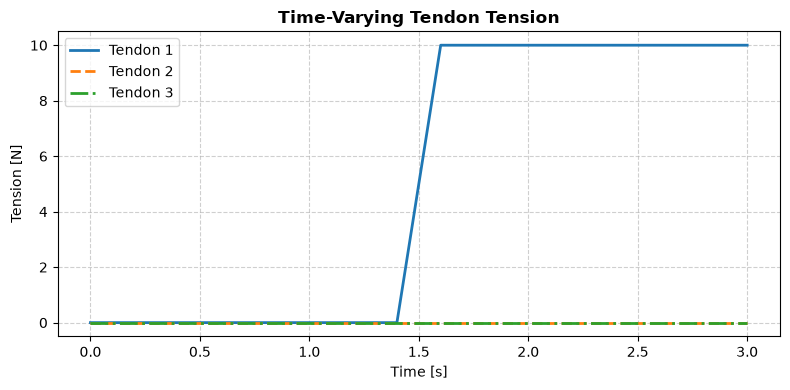

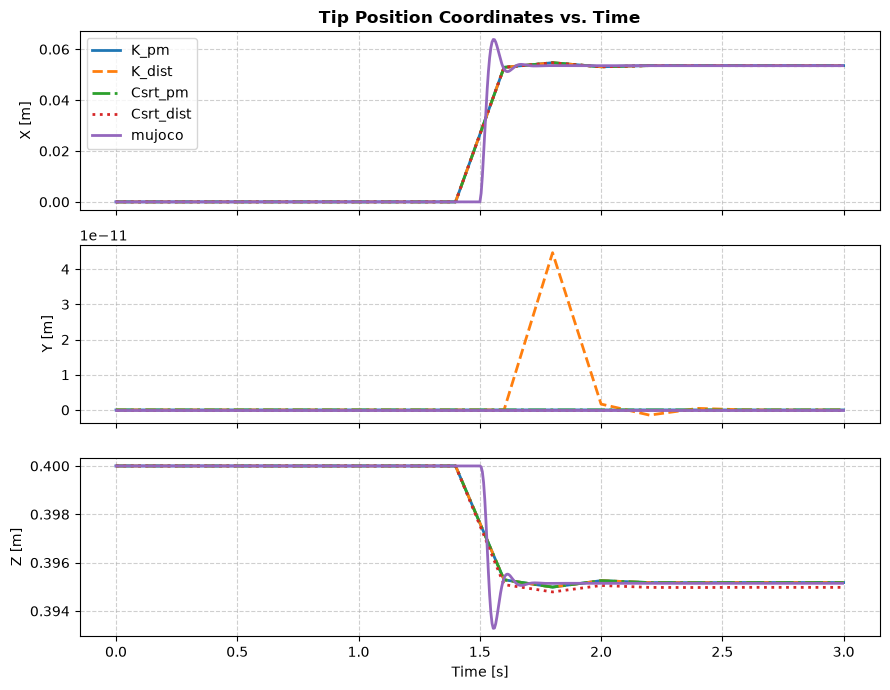

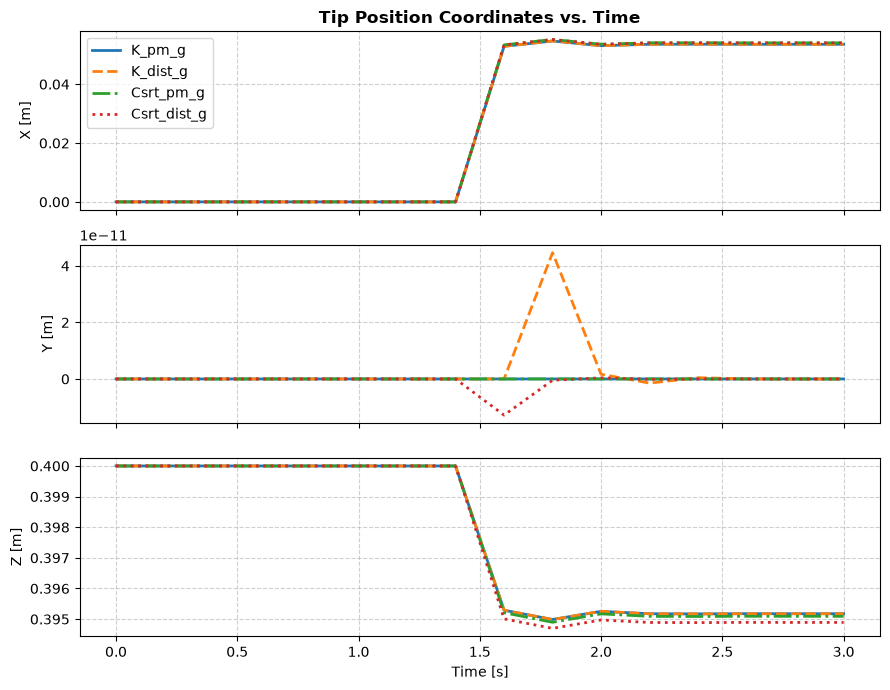

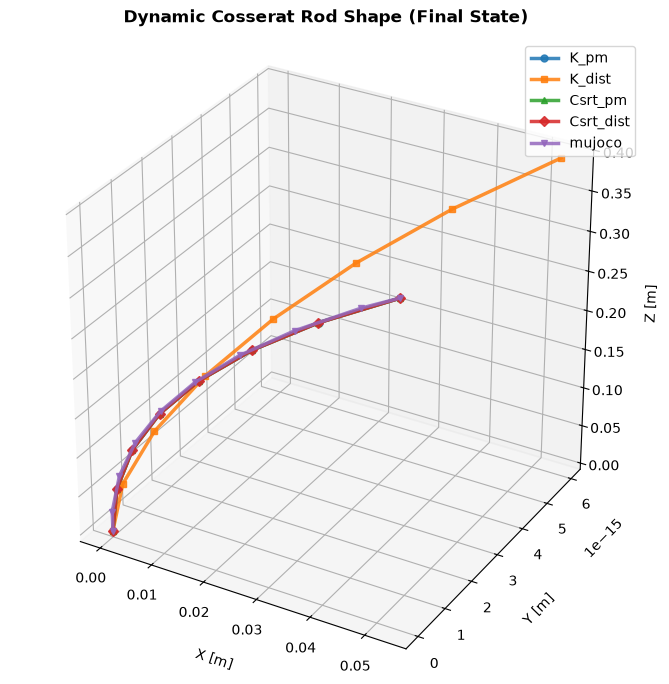

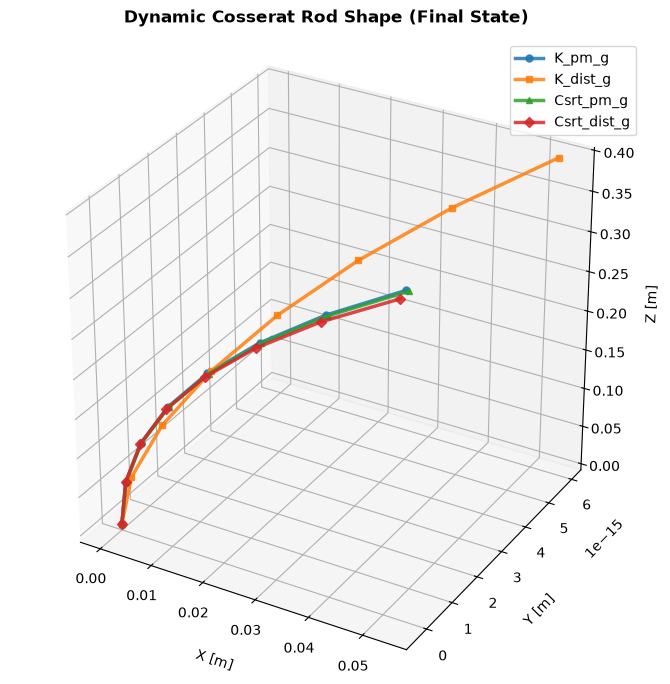

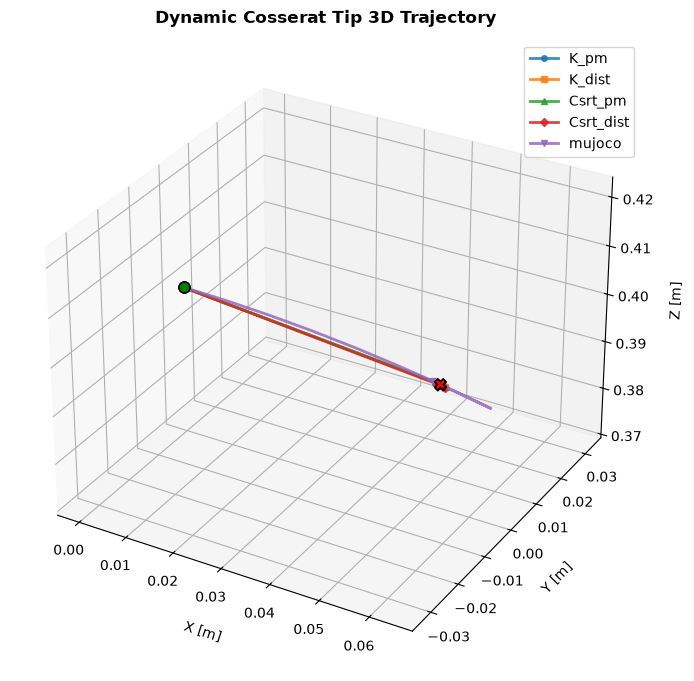

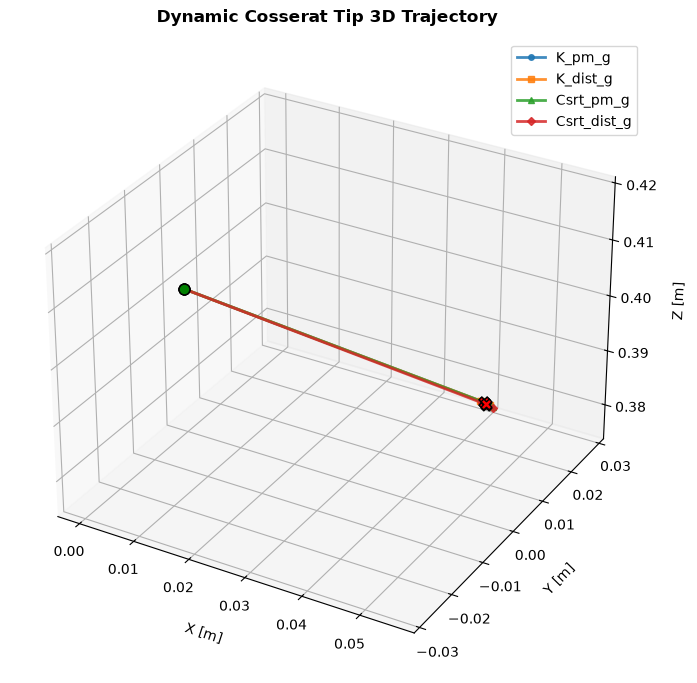

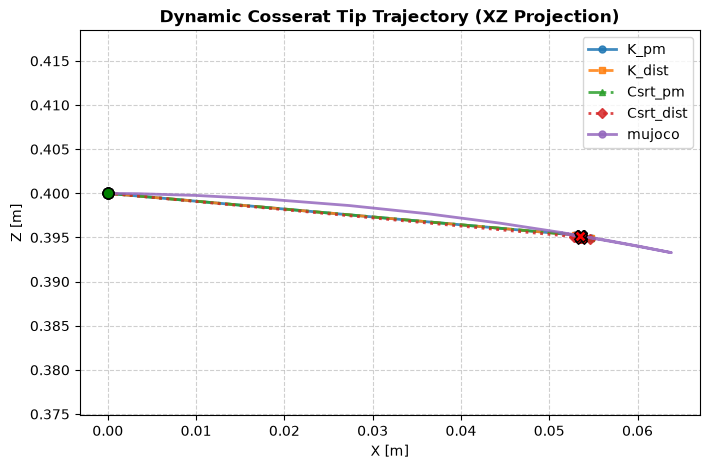

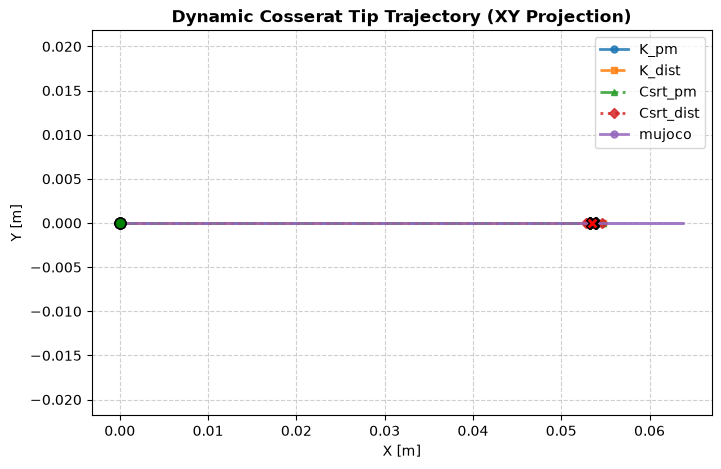

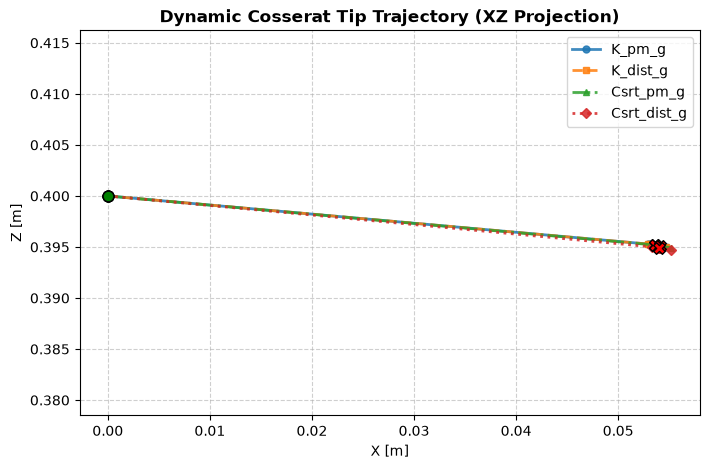

In [85]:
# ============================================================
# 7. MAIN
# ============================================================
if __name__ == "__main__":

    # TENDON TENSIONS
    def pulse(t,t_on,t_off,T=10.0,tau=0.02): return 0.5*T*(np.tanh((t-t_on)/tau)-np.tanh((t-t_off)/tau))
    def T1(t): return 10 if t > t_final/2 else 0#pulse(t,0.0,2/3)+pulse(t,2.0,8/3) #10*(np.cos(np.pi*t)) if np.cos(np.pi*t) > 0 else 0#
    def T2(t): return 0.0 #pulse(t,2/3,4/3)+pulse(t,8/3,10/3) #10*(np.sin(np.pi*t)) if np.sin(np.pi*t) > 0 else 0#
    def T3(t): return 0.0 #pulse(t,4/3,2.0)+pulse(t,10/3,4.0) #10*(np.cos(np.pi+np.pi*t)) if np.cos(np.pi+np.pi*t) > 0 else 0#
    tension_func = [T1,T2,T3]
    
    tendon_1 = make_straight_tendon(radius=tendon_radius, angle=A1, tension_function=tension_func[0], name="Tendon 1")
    tendon_2 = make_straight_tendon(radius=tendon_radius, angle=A2, tension_function=tension_func[1], name="Tendon 2")
    tendon_3 = make_straight_tendon(radius=tendon_radius, angle=A3, tension_function=tension_func[2], name="Tendon 3")
    print("p_1",tendon_1)
    print("p_2",tendon_2)
    print("p_3",tendon_3)
    tendons = [tendon_1, tendon_2, tendon_3]

    # KIRCHHOFF ROD SOLVER
    k_rod = DynamicCosserat_Kirchhoff(L=L, E=E, G=G, radius=radius, density=density, crt=False)
    k_solver = DynamicCosseratSolver(rod=k_rod, tendons=tendons, dt=dt, gravity=np.zeros(3),
        tip_force=np.array([0,0,0]), tip_moment=np.zeros(3), rtol=1e-6, atol=1e-6,  max_step=ds)

    # COSSERAT ROD SOLVER
    c_rod = DynamicCosserat_Kirchhoff(L=L, E=E, G=G, radius=radius, density=density, crt=True)
    c_solver = DynamicCosseratSolver(rod=c_rod, tendons=tendons, dt=dt, gravity=gravity,
            tip_force=np.array([0,0,0]), tip_moment=np.zeros(3), rtol=1e-6, atol=1e-6,  max_step=ds)

    # OPENCR MUJOCO
    parser = argparse.ArgumentParser()
    parser.add_argument("--xml", default=r"C:\Manoj\Mtech_project\opencr-mujoco\mujoco_xml\1seg_tdcr.xml")
    parser.add_argument("--seconds", type=float, default=60.0)
    args, unknown = parser.parse_known_args()
    model, data = load_model(args.xml)
    act_ids = get_actuator_ids(model)

    # KIRCHHOFF ROD THEORY
    # Point moment
    result1 = k_solver.simulate(time_array=time_array, num_points=N, print_progress=False,dt=False,g=False,pm=True)
    # Point moment with gravity
    result2 = k_solver.simulate(time_array=time_array, num_points=N, print_progress=False,dt=False,g=True, pm=True)
    # Distributed load
    result3 = k_solver.simulate(time_array=time_array, num_points=N, print_progress=False,dt=True, g=False,pm=False)
    # Distributed load with gravity
    result4 = k_solver.simulate(time_array=time_array, num_points=N, print_progress=False,dt=True, g=True, pm=False)

    # COSSERAT ROD THEORY
    # Point moment
    result5 = c_solver.simulate(time_array=time_array, num_points=N, print_progress=False,dt=False,g=False,pm=True)
    # Point moment with gravity
    result6 = c_solver.simulate(time_array=time_array, num_points=N, print_progress=False,dt=False,g=True, pm=True)
    # Distributed load
    result7 = c_solver.simulate(time_array=time_array, num_points=N, print_progress=False,dt=True, g=False,pm=False)
    # Distributed load with gravity
    result8 = c_solver.simulate(time_array=time_array, num_points=N, print_progress=False,dt=True, g=True, pm=False)
   
    # MuJoCo controller
    controller = FlexibleTendonController(num_actuators=model.nu, step=0.2, maximum=10, tension_funcs=tension_func)
    with mujoco.viewer.launch_passive(model, data, key_callback=controller.key_callback) as viewer:
        result9 = forward_dynamics_interactive(model, data, viewer, controller, act_ids, t_final=t_final)

    results  = [result1, result3, result5, result7, result9]
    labels   = ["K_pm", "K_dist","Csrt_pm","Csrt_dist","mujoco"] 

    results2 = [result2, result4, result6, result8]
    labels2  = ["K_pm_g", "K_dist_g", "Csrt_pm_g", "Csrt_dist_g"]

    plot_tensions(result1["time"], tendons)
    
    plot_tip_coordinates(results, labels)
    plot_tip_coordinates(results2, labels2)

    plot_backbone_snapshots(results, labels)
    plot_backbone_snapshots(results2, labels2)

    plot_tip_trajectory(results, labels)
    plot_tip_trajectory(results2, labels2)

    plot_tip_trajectory2(results, labels)
    plot_tip_trajectory2(results, labels, plane="XY")
    plot_tip_trajectory2(results2, labels2)
    
    
    

 Running Simulation Case: Step Load
MuJoCo Model Loaded: nq=24, nv=24, nu=3, ntendon=3
Actuators: ['seg_0_ten_0', 'seg_0_ten_1', 'seg_0_ten_2']
Plotting results for loading condition: Step Load


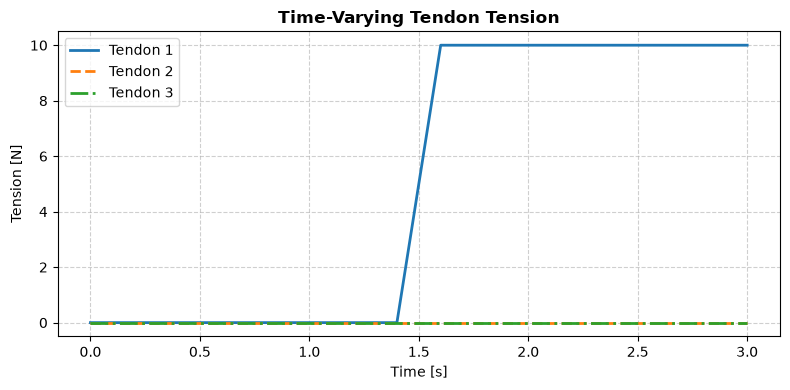

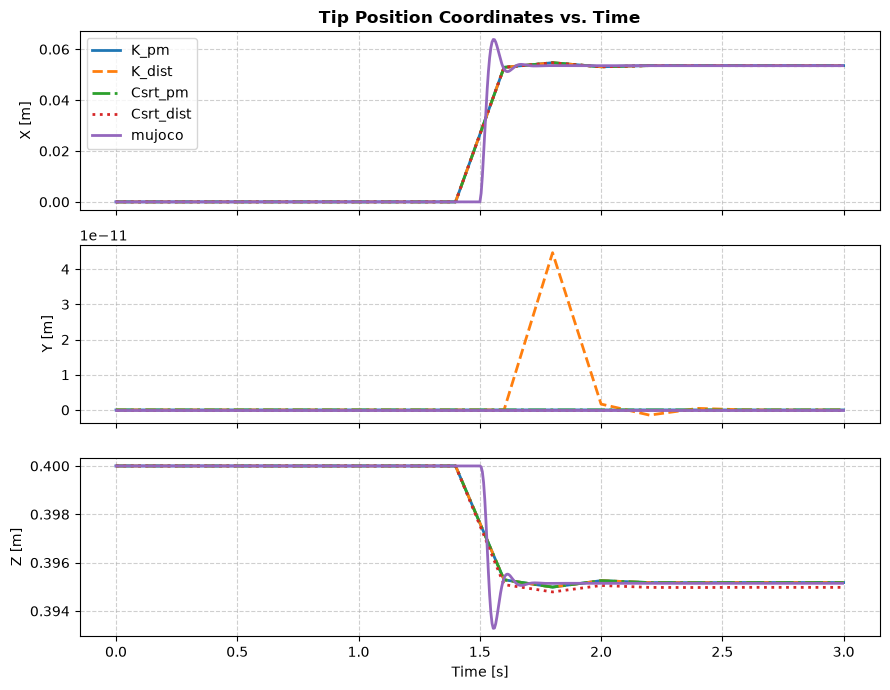

 Running Simulation Case: Linear Ramp
MuJoCo Model Loaded: nq=24, nv=24, nu=3, ntendon=3
Actuators: ['seg_0_ten_0', 'seg_0_ten_1', 'seg_0_ten_2']
Plotting results for loading condition: Linear Ramp


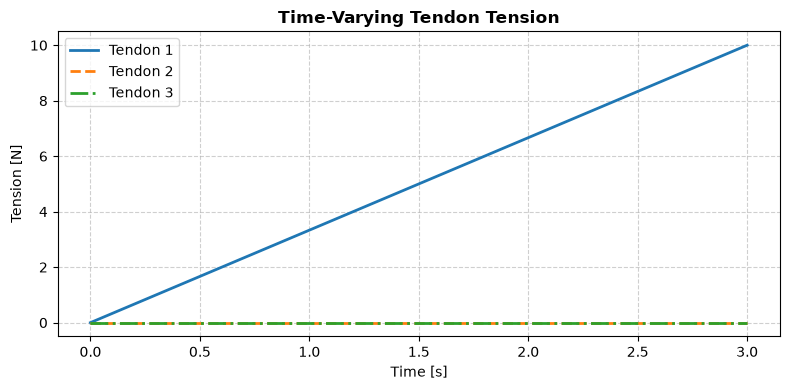

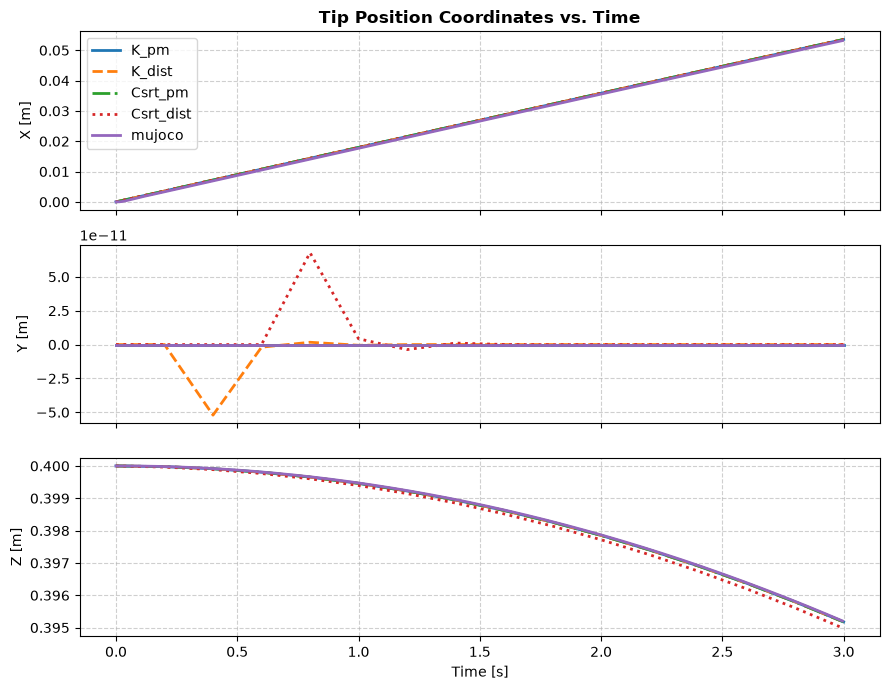

 Running Simulation Case: Parabolic Ramp
MuJoCo Model Loaded: nq=24, nv=24, nu=3, ntendon=3
Actuators: ['seg_0_ten_0', 'seg_0_ten_1', 'seg_0_ten_2']
Plotting results for loading condition: Parabolic Ramp


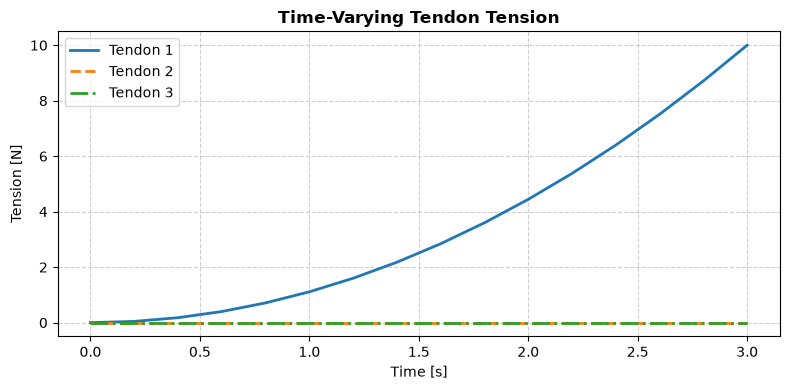

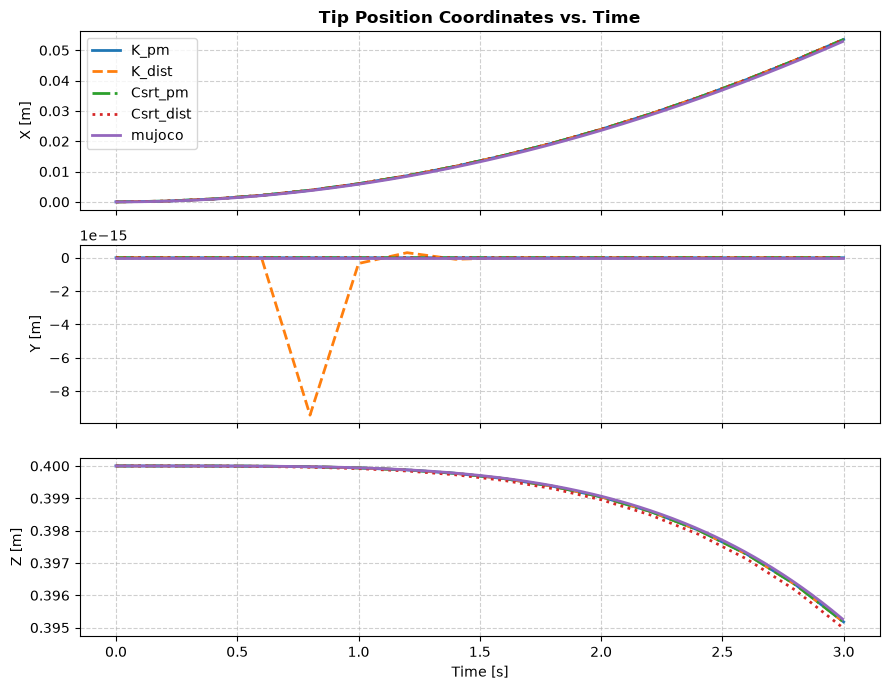

 Running Simulation Case: Sinusoidal Loading
MuJoCo Model Loaded: nq=24, nv=24, nu=3, ntendon=3
Actuators: ['seg_0_ten_0', 'seg_0_ten_1', 'seg_0_ten_2']


C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\linalg\_linalg.py:2767: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)
C:\Users\HP\AppData\Local\Temp\ipykernel_12552\500396130.py:139: RuntimeWarning: overflow encountered in matmul
  D = (hat_p @ hat_p) / (p_i_s_norm**3)
C:\Users\HP\AppData\Local\Temp\ipykernel_12552\500396130.py:139: RuntimeWarning: invalid value encountered in divide
  D = (hat_p @ hat_p) / (p_i_s_norm**3)
C:\Users\HP\AppData\Local\Temp\ipykernel_12552\500396130.py:146: RuntimeWarning: overflow encountered in matmul
  P0 = R @ H0
C:\Users\HP\AppData\Local\Temp\ipykernel_12552\500396130.py:284: RuntimeWarning: overflow encountered in matmul
  p_tt = R @ (q_t + hat_w @ q)
C:\Users\HP\AppData\Local\Temp\ipykernel_12552\500396130.py:284: RuntimeWarning: invalid value encountered in matmul
  p_tt = R @ (q_t + hat_w @ q)
C:\Users\HP\AppData\Local\Temp\ipykernel_125

Plotting results for loading condition: Sinusoidal Loading


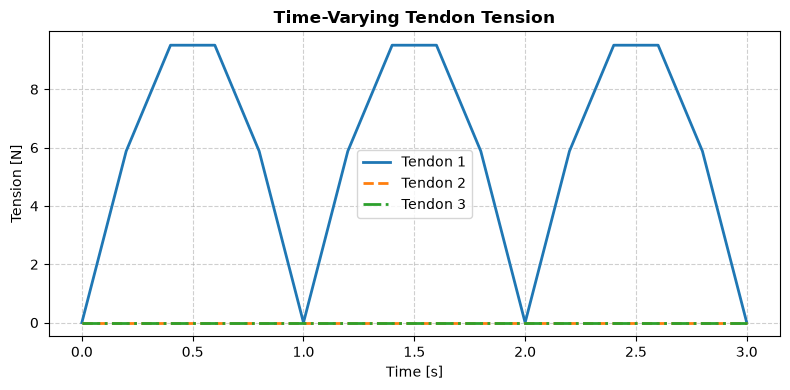

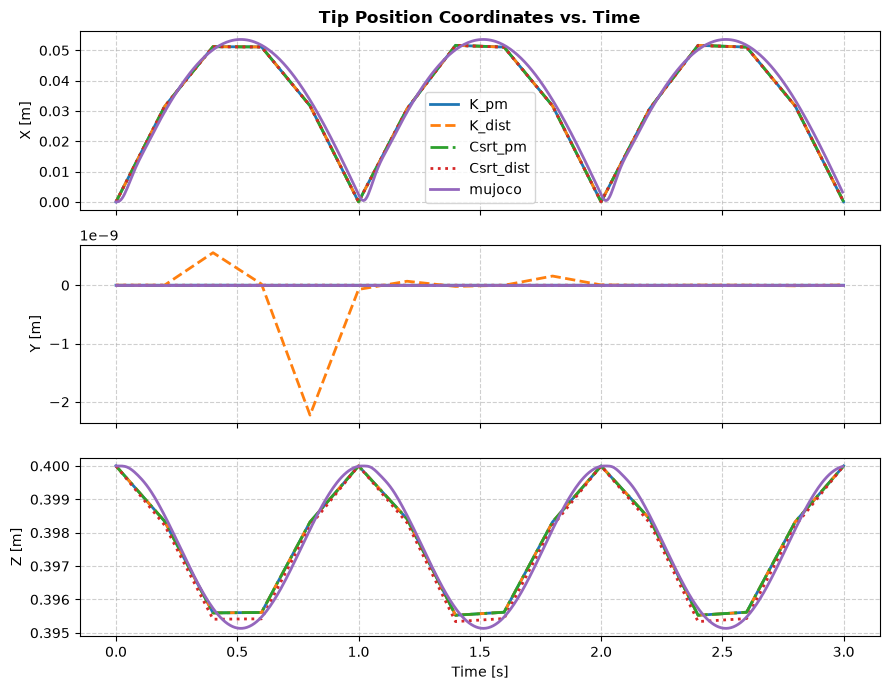

 Running Simulation Case: Multi Step Load
MuJoCo Model Loaded: nq=24, nv=24, nu=3, ntendon=3
Actuators: ['seg_0_ten_0', 'seg_0_ten_1', 'seg_0_ten_2']
Plotting results for loading condition: Multi Step Load


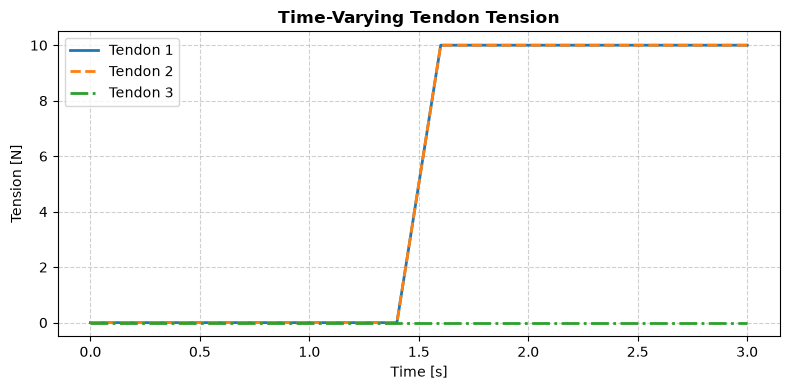

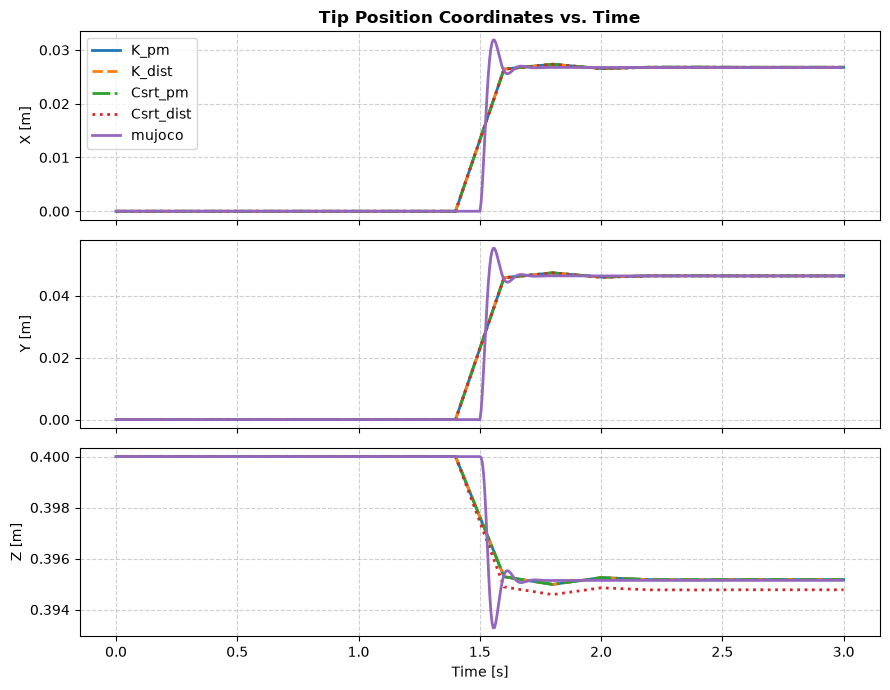

 Running Simulation Case: Multi Linear Ramp
MuJoCo Model Loaded: nq=24, nv=24, nu=3, ntendon=3
Actuators: ['seg_0_ten_0', 'seg_0_ten_1', 'seg_0_ten_2']
Plotting results for loading condition: Multi Linear Ramp


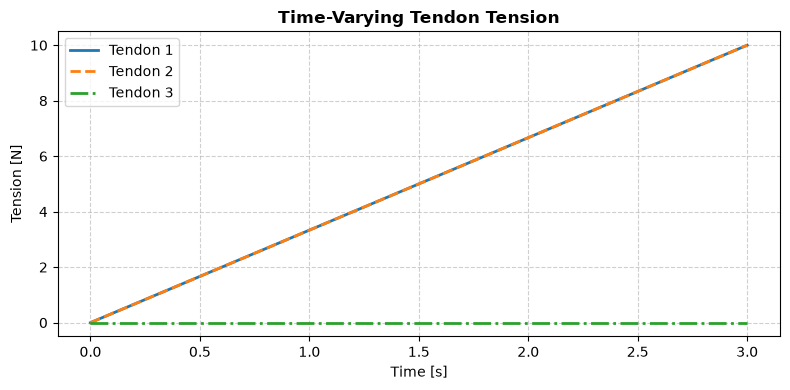

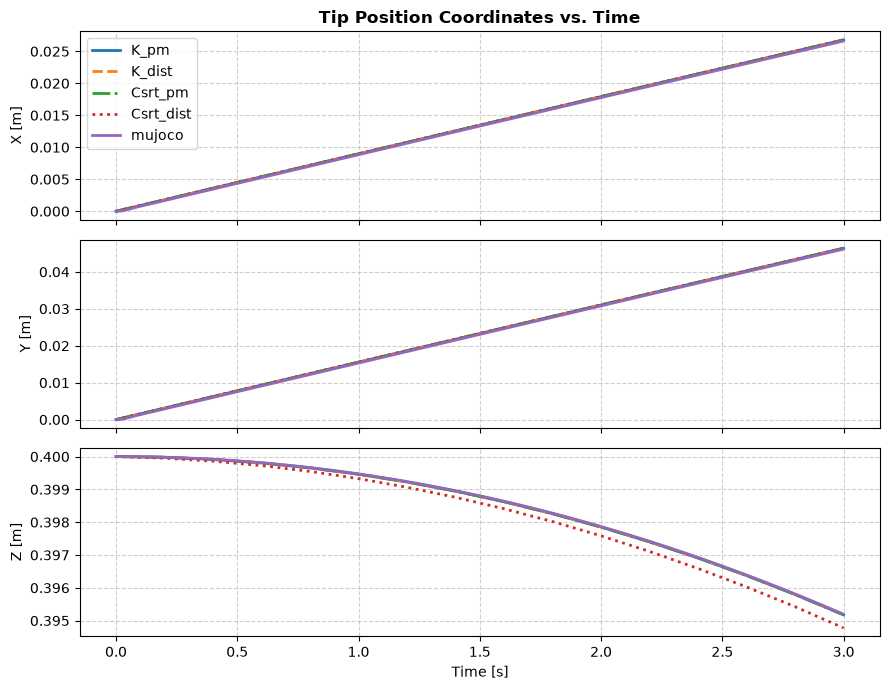

 Running Simulation Case: Multi Parabolic Ramp
MuJoCo Model Loaded: nq=24, nv=24, nu=3, ntendon=3
Actuators: ['seg_0_ten_0', 'seg_0_ten_1', 'seg_0_ten_2']
Plotting results for loading condition: Multi Parabolic Ramp


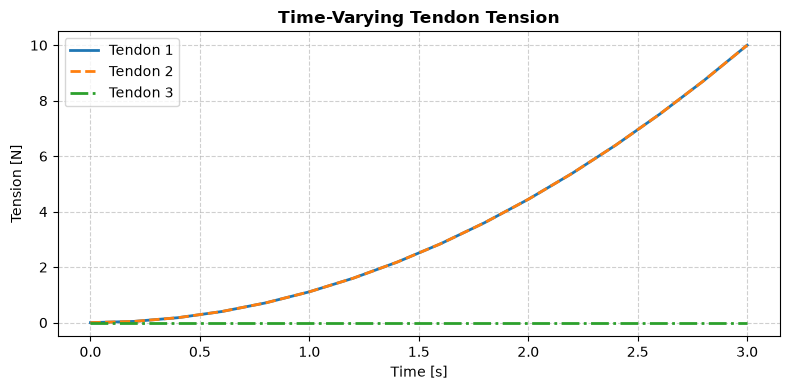

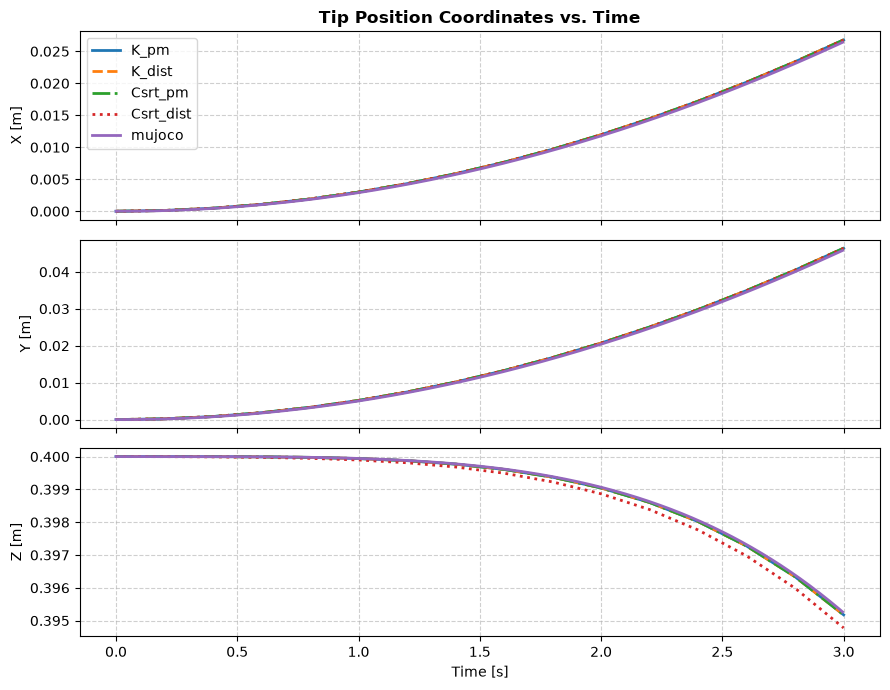

 Running Simulation Case: Multi Sinusoidal Loading
MuJoCo Model Loaded: nq=24, nv=24, nu=3, ntendon=3
Actuators: ['seg_0_ten_0', 'seg_0_ten_1', 'seg_0_ten_2']
Plotting results for loading condition: Multi Sinusoidal Loading


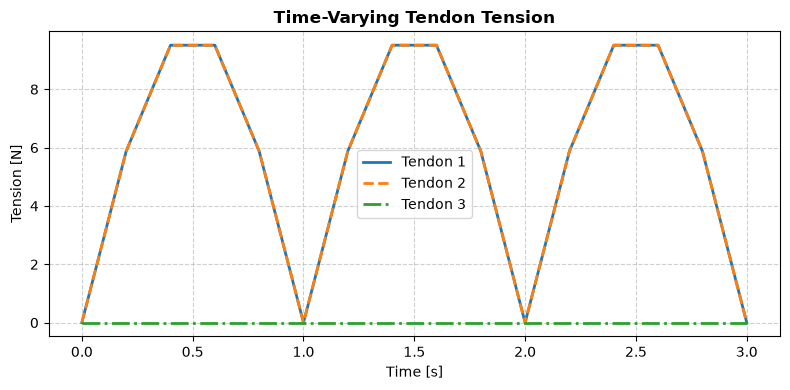

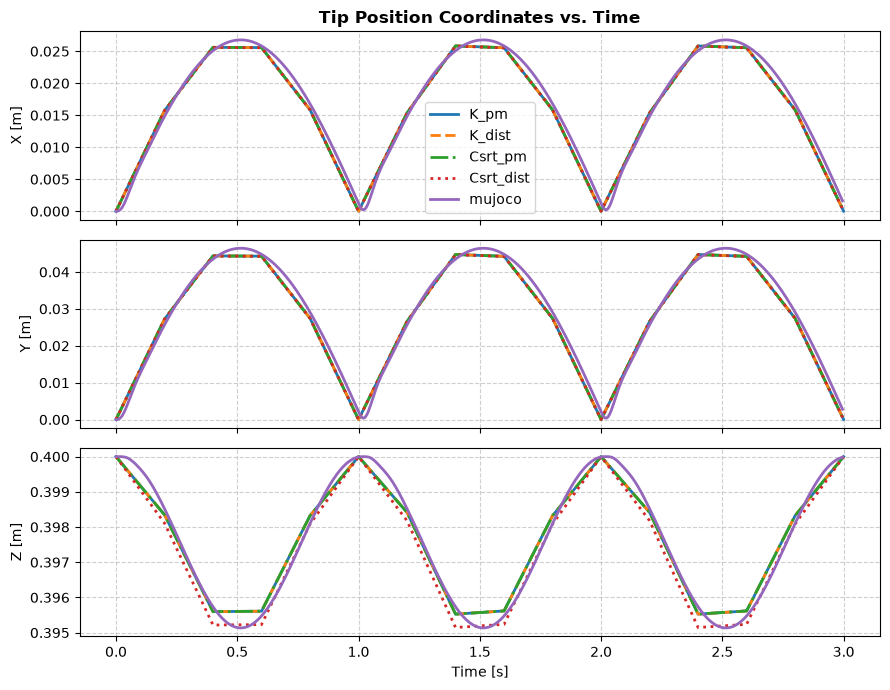

 Running Simulation Case: Multi Cos Actuation
MuJoCo Model Loaded: nq=24, nv=24, nu=3, ntendon=3
Actuators: ['seg_0_ten_0', 'seg_0_ten_1', 'seg_0_ten_2']
Plotting results for loading condition: Multi Cos Actuation


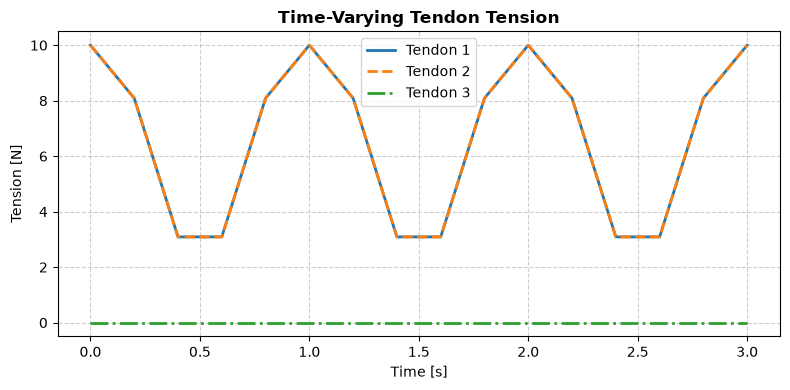

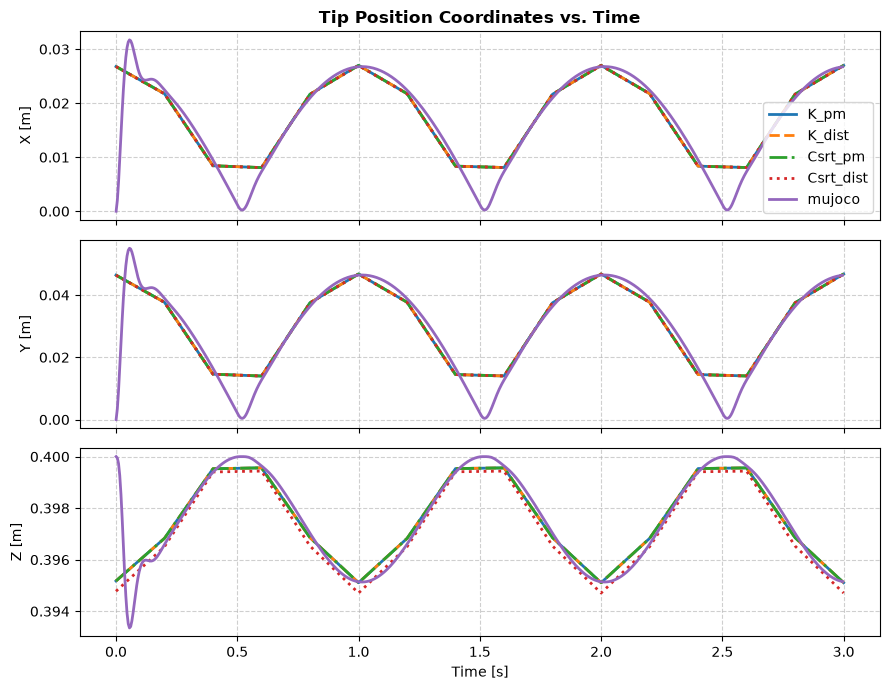

 Running Simulation Case: Multi Vary Step Load
MuJoCo Model Loaded: nq=24, nv=24, nu=3, ntendon=3
Actuators: ['seg_0_ten_0', 'seg_0_ten_1', 'seg_0_ten_2']


C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\_core\numeric.py:1710: RuntimeWarning: overflow encountered in multiply
  multiply(a1, b2, out=cp0)
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\_core\numeric.py:1711: RuntimeWarning: overflow encountered in multiply
  tmp = np.multiply(a2, b1, out=...)
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\_core\numeric.py:1712: RuntimeWarning: invalid value encountered in subtract
  cp0 -= tmp
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\_core\numeric.py:1713: RuntimeWarning: overflow encountered in multiply
  multiply(a2, b0, out=cp1)
C:\Users\HP\AppData\Local\Package

C:\Users\HP\AppData\Local\Temp\ipykernel_12552\500396130.py:122: RuntimeWarning: overflow encountered in matmul
  u_s_cnst = self.rod.u_star_s - self.rod.Kbt_inv @ hat_u @ m_body
C:\Users\HP\AppData\Local\Temp\ipykernel_12552\500396130.py:141: RuntimeWarning: invalid value encountered in matmul
  u_s_const_cross_rho = -hat_rho @ u_s_cnst
C:\Users\HP\AppData\Local\Temp\ipykernel_12552\500396130.py:142: RuntimeWarning: overflow encountered in matmul
  H0 = hat_u @ g + u_s_const_cross_rho + hat_u @ rho_s + rho_ss + v_s_cnst
C:\Users\HP\AppData\Local\Temp\ipykernel_12552\500396130.py:147: RuntimeWarning: overflow encountered in matmul
  Pn = R @ Hn


C:\Users\HP\AppData\Local\Temp\ipykernel_12552\500396130.py:139: RuntimeWarning: overflow encountered in scalar power
  D = (hat_p @ hat_p) / (p_i_s_norm**3)
C:\Users\HP\AppData\Local\Temp\ipykernel_12552\500396130.py:115: RuntimeWarning: overflow encountered in matmul
  v_s_cnst = self.rod.v_star_s - self.rod.Kse_inv @ hat_u @ n_body
C:\Users\HP\AppData\Local\Temp\ipykernel_12552\500396130.py:132: RuntimeWarning: overflow encountered in matmul
  p_i_s = R @ g
C:\Users\HP\AppData\Local\Temp\ipykernel_12552\500396130.py:139: RuntimeWarning: invalid value encountered in matmul
  D = (hat_p @ hat_p) / (p_i_s_norm**3)
C:\Users\HP\AppData\Local\Temp\ipykernel_12552\500396130.py:116: RuntimeWarning: invalid value encountered in matmul
  Vn = self.rod.Kse_inv @ R.T
C:\Users\HP\AppData\Local\Temp\ipykernel_12552\500396130.py:121: RuntimeWarning: invalid value encountered in matmul
  Um = self.rod.Kbt_inv @ R.T
C:\Users\HP\AppData\Local\Temp\ipykernel_12552\500396130.py:147: RuntimeWarning: inv

Plotting results for loading condition: Multi Vary Step Load


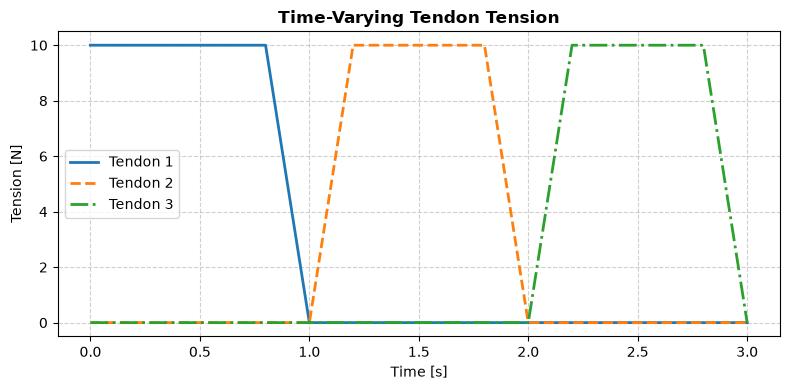

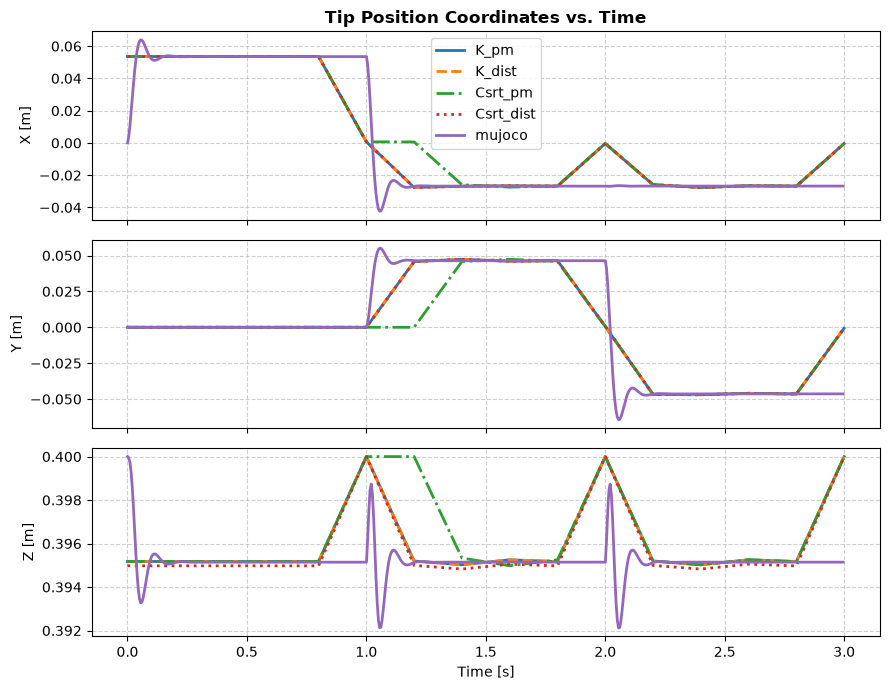

 Running Simulation Case: Multi-Tendon Actuation
MuJoCo Model Loaded: nq=24, nv=24, nu=3, ntendon=3
Actuators: ['seg_0_ten_0', 'seg_0_ten_1', 'seg_0_ten_2']
Plotting results for loading condition: Multi-Tendon Actuation


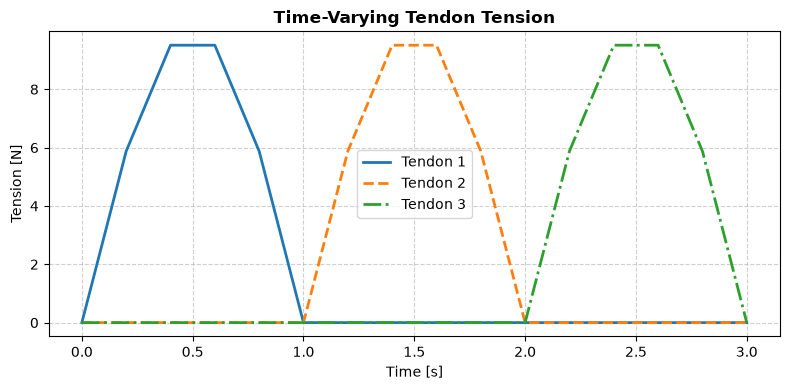

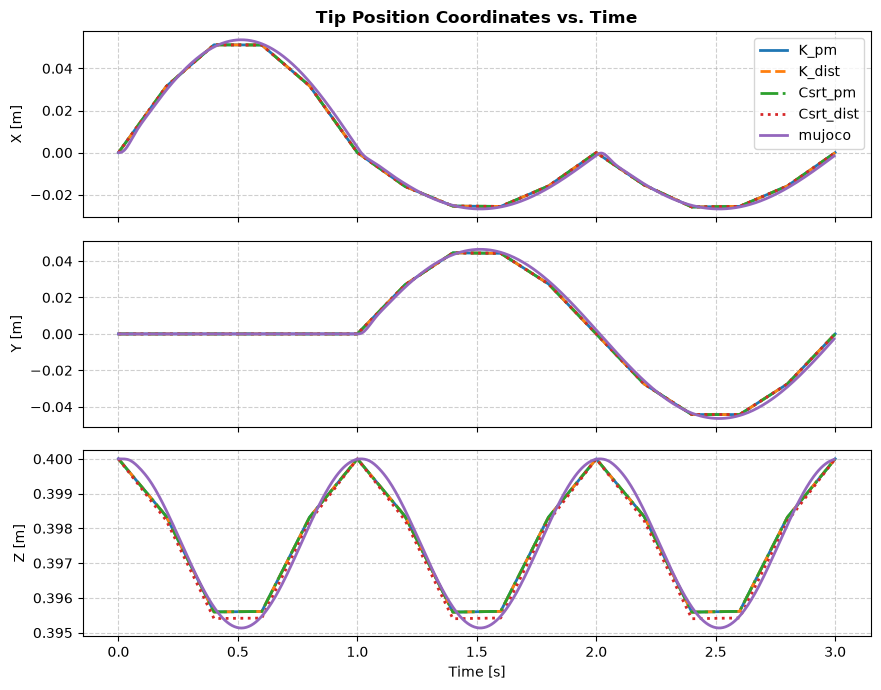

 Running Simulation Case: Multi COS_SIN Actuation
MuJoCo Model Loaded: nq=24, nv=24, nu=3, ntendon=3
Actuators: ['seg_0_ten_0', 'seg_0_ten_1', 'seg_0_ten_2']
Plotting results for loading condition: Multi COS_SIN Actuation


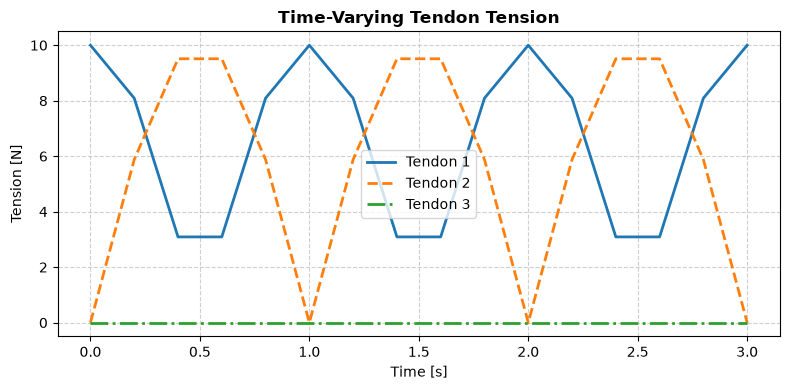

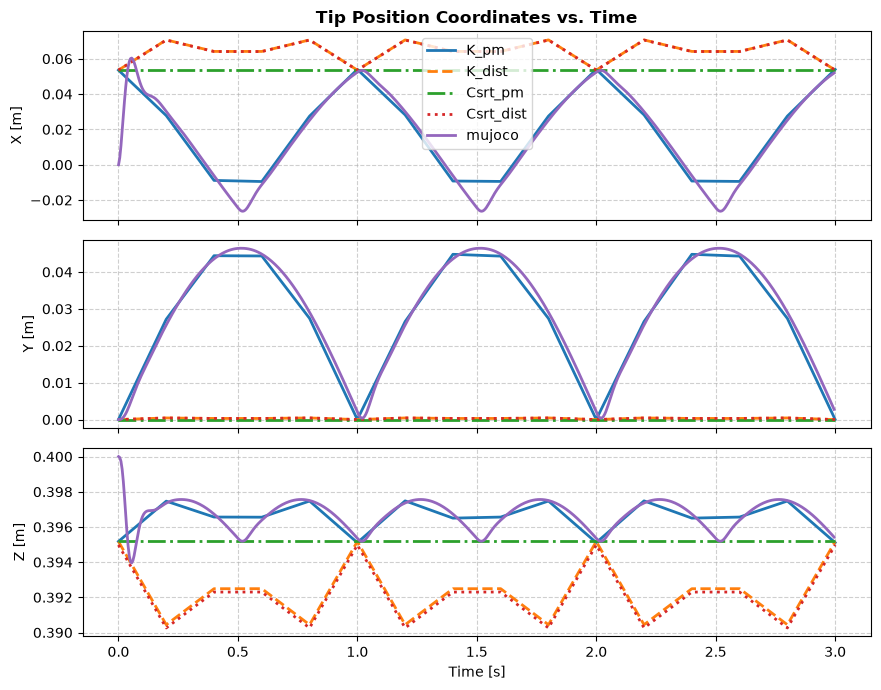

In [86]:
# ============================================================
# 7. MAIN
# ============================================================
if __name__ == "__main__":
    
    # DEFINE DIFFERENT LOADING CONDITIONS
    load_cases = {
        "Step Load": [
            lambda t: 10.0 if t >t_final/2 else 0.0,
            lambda t: 0.0,
            lambda t: 0.0
        ],
        "Linear Ramp": [
            lambda t: 10/3 * t,
            lambda t: 0.0,
            lambda t: 0.0
        ],
        "Parabolic Ramp": [
            lambda t: 10/9*t**2,
            lambda t: 0.0,
            lambda t: 0.0
        ],
        "Sinusoidal Loading": [
            lambda t: 10.0 * np.abs(np.sin(np.pi * t)),
            lambda t: 0.0,
            lambda t: 0.0
        ],
        "Multi Step Load": [
            lambda t: 10.0 if t >t_final/2 else 0.0,
            lambda t: 10.0 if t >t_final/2 else 0.0,
            lambda t: 0.0
        ],
        "Multi Linear Ramp": [
            lambda t: 10/3* t,
            lambda t: 10/3 * t,
            lambda t: 0.0
        ],
        "Multi Parabolic Ramp": [
            lambda t: 10/9*t**2,
            lambda t: 10/9*t**2,
            lambda t: 0.0
        ],
        "Multi Sinusoidal Loading": [
            lambda t: 10.0 * np.abs(np.sin(np.pi * t)),
            lambda t: 10.0 * np.abs(np.sin(np.pi * t)),
            lambda t: 0.0
        ],
        "Multi Cos Actuation": [
            lambda t: 10.0 * np.abs(np.cos(np.pi * t)),
            lambda t: 10.0 * np.abs(np.cos(np.pi * t)),
            lambda t: 0.0
        ],
        "Multi Vary Step Load": [
            lambda t: 10.0 if t < t_final/3 else 0.0,
            lambda t: 10.0 if 2*t_final/3 > t > t_final/3 else 0.0,
            lambda t: 10.0 if t_final > t > 2*t_final/3 else 0.0,
        ],
        "Multi-Tendon Actuation": [
            lambda t: 10.0 * np.abs(np.sin(np.pi * t)) if t <= 1 else 0.0,
            lambda t: 10.0 * np.abs(np.sin(np.pi * t)) if 1 < t <= 2 else 0.0,
            lambda t: 10.0 * np.abs(np.sin(np.pi * t)) if 2 < t <= 3 else 0.0
        ],
        "Multi COS_SIN Actuation": [
            lambda t: 10.0 * np.abs(np.cos(np.pi * t)),
            lambda t: 10.0 * np.abs(np.sin(np.pi * t)),
            lambda t: 0.0
        ],
    }

    # Dict to store trajectory comparison results across load cases
    all_case_results = {}

    # Iterate over each loading condition to observe model behaviors
    for case_name, tension_func in load_cases.items():
        print(f" Running Simulation Case: {case_name}")
        
        # 1. Setup Tendons for current loading condition
        tendon_1 = make_straight_tendon(radius=tendon_radius, angle=A1, tension_function=tension_func[0], name="Tendon 1")
        tendon_2 = make_straight_tendon(radius=tendon_radius, angle=A2, tension_function=tension_func[1], name="Tendon 2")
        tendon_3 = make_straight_tendon(radius=tendon_radius, angle=A3, tension_function=tension_func[2], name="Tendon 3")
        tendons = [tendon_1, tendon_2, tendon_3]

        # 2. SOLVER
        # KIRCHHOFF ROD SOLVER
        k_rod = DynamicCosserat_Kirchhoff(L=L, E=E, G=G, radius=radius, density=density, crt=False)
        k_solver = DynamicCosseratSolver(rod=k_rod, tendons=tendons, dt=dt, gravity=np.zeros(3),
            tip_force=np.array([0,0,0]), tip_moment=np.zeros(3), rtol=1e-6, atol=1e-6,  max_step=ds)
    
        # COSSERAT ROD SOLVER
        c_rod = DynamicCosserat_Kirchhoff(L=L, E=E, G=G, radius=radius, density=density, crt=True)
        c_solver = DynamicCosseratSolver(rod=c_rod, tendons=tendons, dt=dt, gravity=gravity,
                tip_force=np.array([0,0,0]), tip_moment=np.zeros(3), rtol=1e-6, atol=1e-6,  max_step=ds)

        # OPENCR MUJOCO
        parser = argparse.ArgumentParser()
        parser.add_argument("--xml", default=r"C:\Manoj\Mtech_project\opencr-mujoco\mujoco_xml\1seg_tdcr.xml")#"C:/Manoj/Mtech_project/mujoco_xml/test1.xml")
        parser.add_argument("--seconds", type=float, default=60.0)
        args, unknown = parser.parse_known_args()
        model, data = load_model(args.xml)
        act_ids = get_actuator_ids(model)

        # 3. RESULTS BY EACH
        # KIRCHHOFF ROD THEORY
        # Point moment
        result1 = k_solver.simulate(time_array=time_array, num_points=N, print_progress=False,dt=False,g=False,pm=True)
        # Point moment with gravity
        result2 = k_solver.simulate(time_array=time_array, num_points=N, print_progress=False,dt=False,g=True, pm=True)
        # Distributed load
        result3 = k_solver.simulate(time_array=time_array, num_points=N, print_progress=False,dt=True, g=False,pm=False)
        # Distributed load with gravity
        result4 = k_solver.simulate(time_array=time_array, num_points=N, print_progress=False,dt=True, g=True, pm=False)
    
        # COSSERAT ROD THEORY
        # Point moment
        result5 = c_solver.simulate(time_array=time_array, num_points=N, print_progress=False,dt=False,g=False,pm=True)
        # Point moment with gravity
        result6 = c_solver.simulate(time_array=time_array, num_points=N, print_progress=False,dt=False,g=True, pm=True)
        # Distributed load
        result7 = c_solver.simulate(time_array=time_array, num_points=N, print_progress=False,dt=True, g=False,pm=False)
        # Distributed load with gravity
        result8 = c_solver.simulate(time_array=time_array, num_points=N, print_progress=False,dt=True, g=True, pm=False)
            
        # OPENCR MUJOCO controller
        controller = FlexibleTendonController(num_actuators=model.nu, step=0.2, maximum=100, tension_funcs=tension_func)
        with mujoco.viewer.launch_passive(model, data, key_callback=controller.key_callback) as viewer:
            result9 = forward_dynamics_interactive(model, data, viewer, controller, act_ids, t_final=t_final)
    
        results_no_gravity  = [result1, result3, result5, result7, result9]
        labels_no_gravity   = ["K_pm", "K_dist","Csrt_pm","Csrt_dist","mujoco"]

        #results_with_gravity = [res_K_dist, res_Csrt_dist, result_sorosim]
        #labels_with_gravity  = ["Kirchhoff (Distributed)", "Cosserat (Distributed)", "SoRoSim"]

        # Store results for comparative summaries
        all_case_results[case_name] = {
            "no_g": (results_no_gravity, labels_no_gravity),
            #"with_g": (results_with_gravity, labels_with_gravity)
        }

        # Plot individual tip trajectories and backbone curves for this specific load case
        print(f"Plotting results for loading condition: {case_name}")
        plot_tensions(result1["time"], tendons)
        plot_tip_coordinates(results_no_gravity, labels_no_gravity)
        #plot_tip_trajectory(results_no_gravity, labels_no_gravity)
        #plot_tip_trajectory2(results_no_gravity, labels_no_gravity, plane="XZ")
        #plot_tip_trajectory2(results_no_gravity, labels_no_gravity, plane="XY")
        #plot_backbone_snapshots(results_no_gravity, labels_no_gravity)